In [159]:
#!/usr/bin/python
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
import stingray as sg
from stingray import Lightcurve, Powerspectrum, Crossspectrum, AveragedCrossspectrum, AveragedPowerspectrum
from stingray.simulator import simulator
import ndspec
from scipy.signal import hilbert
pi = np.pi

sign_char = lambda x: '+' if x > 0 else '-'

#
def make_decaying_sine(constant, factor, nu, Dnu, phi, t, kick=False, kick_period = 0.2, phase=0):
    """Decaying sine-wave"""
    alpha = np.pi * Dnu
    if kick == False:
        return constant + factor*constant*np.exp(-alpha * np.abs(t)) * np.sin(2*np.pi*nu*t - 2*np.pi*phi + phase)
    else:
        total_kicks = np.max(t) // kick_period + 1
        time_scatter_per_kick = np.random.normal(1, 0.1, int(total_kicks)) * kick_period
        print(time_scatter_per_kick, total_kicks)
        time = []
        i = 0
        j = 0
        t_i = t[i]
        kick_j = time_scatter_per_kick[j]
        while t_i < np.max(t):
            time_block = constant + factor*constant*np.exp(-alpha * np.abs(t_i%kick_j)) * np.sin(2*np.pi*nu*(t_i%kick_j) - 2*np.pi*phi)
            print(time_block)
            time.append(time_block)
            i += 1
            if t[i] >= sum(time_scatter_per_kick[:j]):
                j += 1
            t_i = t[i]
            if j >= len(time_scatter_per_kick):
                break
            else:
                kick_j = time_scatter_per_kick[j]
        return np.array(time)

def sine_wave_distort(x1, x2, constant):
    """Distort a sine wave by a power law."""
    return constant*(x1 + x2)

#
def gen_noise(x, dt=0.125, rms=1.0, beta=2):
    """Adding some noise à la Timmer & Koenig"""

    sim = simulator.Simulator(N=len(x), mean=10, dt=dt, rms=rms)
    lc = sim.simulate(beta)
    return lc + x

def gen_noise_original(time, x, fmin=1e-3, fmax=1e2, nfreq=1e2, beta=1.0, norm=1):
    """Adding some noise à la Timmer & Koenig"""

    freqs = 10**((np.log10(fmax) - np.log10(fmin)) *  np.linspace(0, 1, int(nfreq)) + np.log10(fmin))

    lc0 = np.mean(x)
    lc = x - lc0

    for ifreq,freq in enumerate(freqs):
        #print(np.round(ifreq/nfreq,2)*100)
        print(norm * (1./freq)**beta * np.cos(2*np.pi*freq*time - np.random.rand()*2*np.pi) / nfreq)
        lc += norm * (1./freq)**beta * np.cos(2*np.pi*freq*time - np.random.rand()*2*np.pi) / nfreq

    return lc - np.mean(lc) + lc0

def kramers_kronig_onesided_fast(freqs, L):
    """Vectorized one-sided Kramers-Kronig."""
    N = len(freqs)
    df = freqs[1] - freqs[0]
    
    # omega[i] and omega'[j] arrays
    w = freqs[:, None]     # (N, 1) - evaluation points
    wp = freqs[None, :]    # (1, N) - integration points
    
    # Denominator: omega'^2 - omega^2
    denom = wp**2 - w**2
    
    # Set diagonal to inf to skip singularity
    np.fill_diagonal(denom, np.inf)
    
    # Integrand matrix
    integrand = L[None, :] / denom  # (N, N)
    
    # Integrate along axis 1, multiply by prefactor
    delta_theta = (2.0 * freqs / np.pi) * np.trapezoid(integrand, dx=df, axis=1)

    return delta_theta

def plot(t_plot,x1_noise,x2_noise,ps1,ps2,omega1,omega2,avgcs12,x_lim_lower,x_lim_upper,
         file = "figures/decaying_sine_wave.png",omega3=None,theory=False,hil=False):
    """
    Plots results

    Parameters
    -----------
    t_plot : array
        Time array for the plot.
    x1_noise : Lightcurve
        Lightcurve object for the first signal with noise.
    x2_noise : Lightcurve
        Lightcurve object for the second signal with noise.
    ps1 : Powerspectrum
        Power spectrum object for the first signal.
    ps2 : Powerspectrum
        Power spectrum object for the second signal.
    omega1 : float
        Frequency of the first signal.
    omega2 : float
        Frequency of the second signal.
    cs12 : Crossspectrum
        Cross spectrum object between the two signals.
    avgcs12 : AveragedCrossspectrum
        Averaged cross spectrum object between the two signals.
    x_lim_lower : float
        Lower limit for the x-axis.
    x_lim_upper : float
        Upper limit for the x-axis.

    """
    fig = plt.figure(figsize=(24, 12))

    ax1=plt.subplot(2,1,1)
    ax1.plot(t_plot, x1_noise.counts, c="#e66101", label=r"$\phi_1$")
    ax1.plot(t_plot, x2_noise.counts, c="#5e3c99", label=r"$\phi_2$")
    ax1.set_xlabel('Time (s)')
    ax1.legend()
    ax1.set_ylabel('Amplitude')
    ax1.set_xlim(0,5)

    ax2=plt.subplot(2,4,5)
    ax2.errorbar(ps1.freq, ps1.freq*ps1.power, yerr=ps1.freq*ps1.power_err, c="#e66101",label=r"$\phi_1$ PSD")
    ax2.errorbar(ps2.freq, ps2.freq*ps2.power, yerr=ps2.freq*ps2.power_err, c="#5e3c99",label=r"$\phi_2$ PSD")
    ax2.axvline(omega1, color="#b2abd2", linestyle='--')
    ax2.axvline(omega2, color="#b2abd2", linestyle='--')
    if omega3 is not None:
        ax2.axvline(omega3, color="#b2abd2", linestyle='--')
    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.legend(loc="lower left")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel(r"Frequency * Power (rms$^2$)")
    ax2.set_ylim(1e-8, 1e-1)
    ax2.set_xlim(x_lim_lower, x_lim_upper)

    ax3=plt.subplot(2,4,6)
    ax3.plot(avgcs12.freq, np.real(avgcs12.power), c="#e66101",label="Real")
    ax3.plot(avgcs12.freq, np.imag(avgcs12.power), c="#5e3c99",label="Imaginary")
    ax3.axvline(omega1, color="#b2abd2", linestyle='--')
    ax3.axvline(omega2, color="#b2abd2", linestyle='--')
    if omega3 is not None:
        ax3.axvline(omega3, color="#b2abd2", linestyle='--')
    ax3.set_yscale('symlog',linthresh=1e-4)
    ax3.set_xscale("log")
    ax3.set_ylabel('Cross-spectrum')
    ax3.legend()
    ax3.set_ylim(-2e-5, 1e-4)
    ax3.set_xlim(x_lim_lower, x_lim_upper)
    ax3.set_xlabel("Frequency (Hz)")

    ax4 = plt.subplot(2,4,7)
    ax4.errorbar(avgcs12.freq, avgcs12.phase_lag()[0], yerr=avgcs12.lag_err, c="#fdb863", label=r"$\phi_1/\phi_2$")
    #ax4.axvline(omega1, color="#b2abd2", linestyle='--')
    #ax4.axvline(omega2, color="#b2abd2", linestyle='--')
    if omega3 is not None:
        ax4.axvline(omega3, color="#b2abd2", linestyle='--')
    if theory == True:
        omegax = omega1
        omegay = omega2
        dampenx = 0.25
        dampeny = 0.5
        numerator = (dampenx)*ps1.freq*(omegay**2 - ps1.freq**2) - (dampeny)*ps2.freq*(omegax**2 - ps2.freq**2)
        denominator = (omega2**2-ps1.freq**2)*(omega1**2-ps1.freq**2) + (dampenx*dampeny)*(ps1.freq)**2
        manual_delta_theta = np.arctan(numerator/denominator)
        theory_corrected = np.angle(avgcs12.power) - manual_delta_theta
        ax4.plot(ps1.freq,manual_delta_theta,label="theory",c="black",ls="--")
        max_phase_pos = 0.5*(np.sqrt(dampenx*dampeny) + np.sqrt(dampenx*dampeny + 4*omegax*omegay))
        max_phase_neg = 0.5*(-np.sqrt(dampenx*dampeny) + np.sqrt(dampenx*dampeny + 4*omegax*omegay))
        #ax4.axvline(max_phase_pos, color="black", linestyle="--")
        #ax4.axvline(max_phase_neg, color="black", linestyle="--")
    if hil == True:
        concat_freq = np.concatenate([-ps1.freq[::-1],ps1.freq])
        subject_band = np.concatenate([ps1.power[::-1],ps1.power])
        ref_band = np.concatenate([ps2.power[::-1],ps2.power])
        #subject_band = ps1.power
        #ref_band = ps2.power
        print(subject_band)
        log_power_ratio = np.log(subject_band/ref_band)
        delta_theta = (np.imag(hilbert(log_power_ratio))/2)[:-(ps2.power.shape[0])]

        #int_delta_theta = -kramers_kronig_onesided_fast(ps1.freq, log_power_ratio)/2
        print(delta_theta)
        corrected_phase = np.angle(avgcs12.power) - delta_theta
        print(corrected_phase)
        ax4.plot(ps1.freq, delta_theta, label="Hilbert", c="black", ls=":")
        ax4.plot(ps1.freq, corrected_phase, label="Corrected", c="red", ls="-")

    ax4.set_xscale("log")
    ax4.set_ylabel('Phase (radians)')
    ax4.set_xlabel("Frequency (Hz)")
    ax4.set_xlim(x_lim_lower, x_lim_upper)
    ax4.set_ylim(np.min(avgcs12.phase_lag()[0][(avgcs12.freq>x_lim_lower)&(avgcs12.freq<x_lim_upper)]), 
                 np.max(avgcs12.phase_lag()[0][(avgcs12.freq>x_lim_lower)&(avgcs12.freq<x_lim_upper)]))
    ax4.legend(loc="upper left")

    ax5 = plt.subplot(2,4,8)
    ax5.plot(avgcs12.freq, avgcs12.coherence()[0], c="#fdb863", label=r"$\phi_1/\phi_2$")
    ax5.axvline(omega1, color="#b2abd2", linestyle='--')
    ax5.axvline(omega2, color="#b2abd2", linestyle='--')
    if omega3 is not None:
        ax5.axvline(omega3, color="#b2abd2", linestyle='--')
    ax5.set_xscale("log")
    ax5.set_ylabel('Coherence')
    ax5.set_xlabel("Frequency (Hz)")
    ax5.set_ylim(0,1.01)
    ax5.set_xlim(x_lim_lower, x_lim_upper)
    #ax5.legend()

    plt.tight_layout()
    plt.savefig(file)
    plt.show()

# Basic simple signal case

100it [00:00, 14651.57it/s]
100it [00:00, 14267.31it/s]
100it [00:00, 7399.19it/s]


[2.80679357e-13 2.80679605e-13 2.80680018e-13 ... 2.80680018e-13
 2.80679605e-13 2.80679357e-13]
[-3.22279697e-07 -8.55761864e-07 -1.50032371e-06 ...  1.61076915e-03
  9.18573247e-04  3.46038236e-04]
[-0.00062224 -0.00124485 -0.00186851 ... -0.001609   -0.0009174
 -0.00034545]


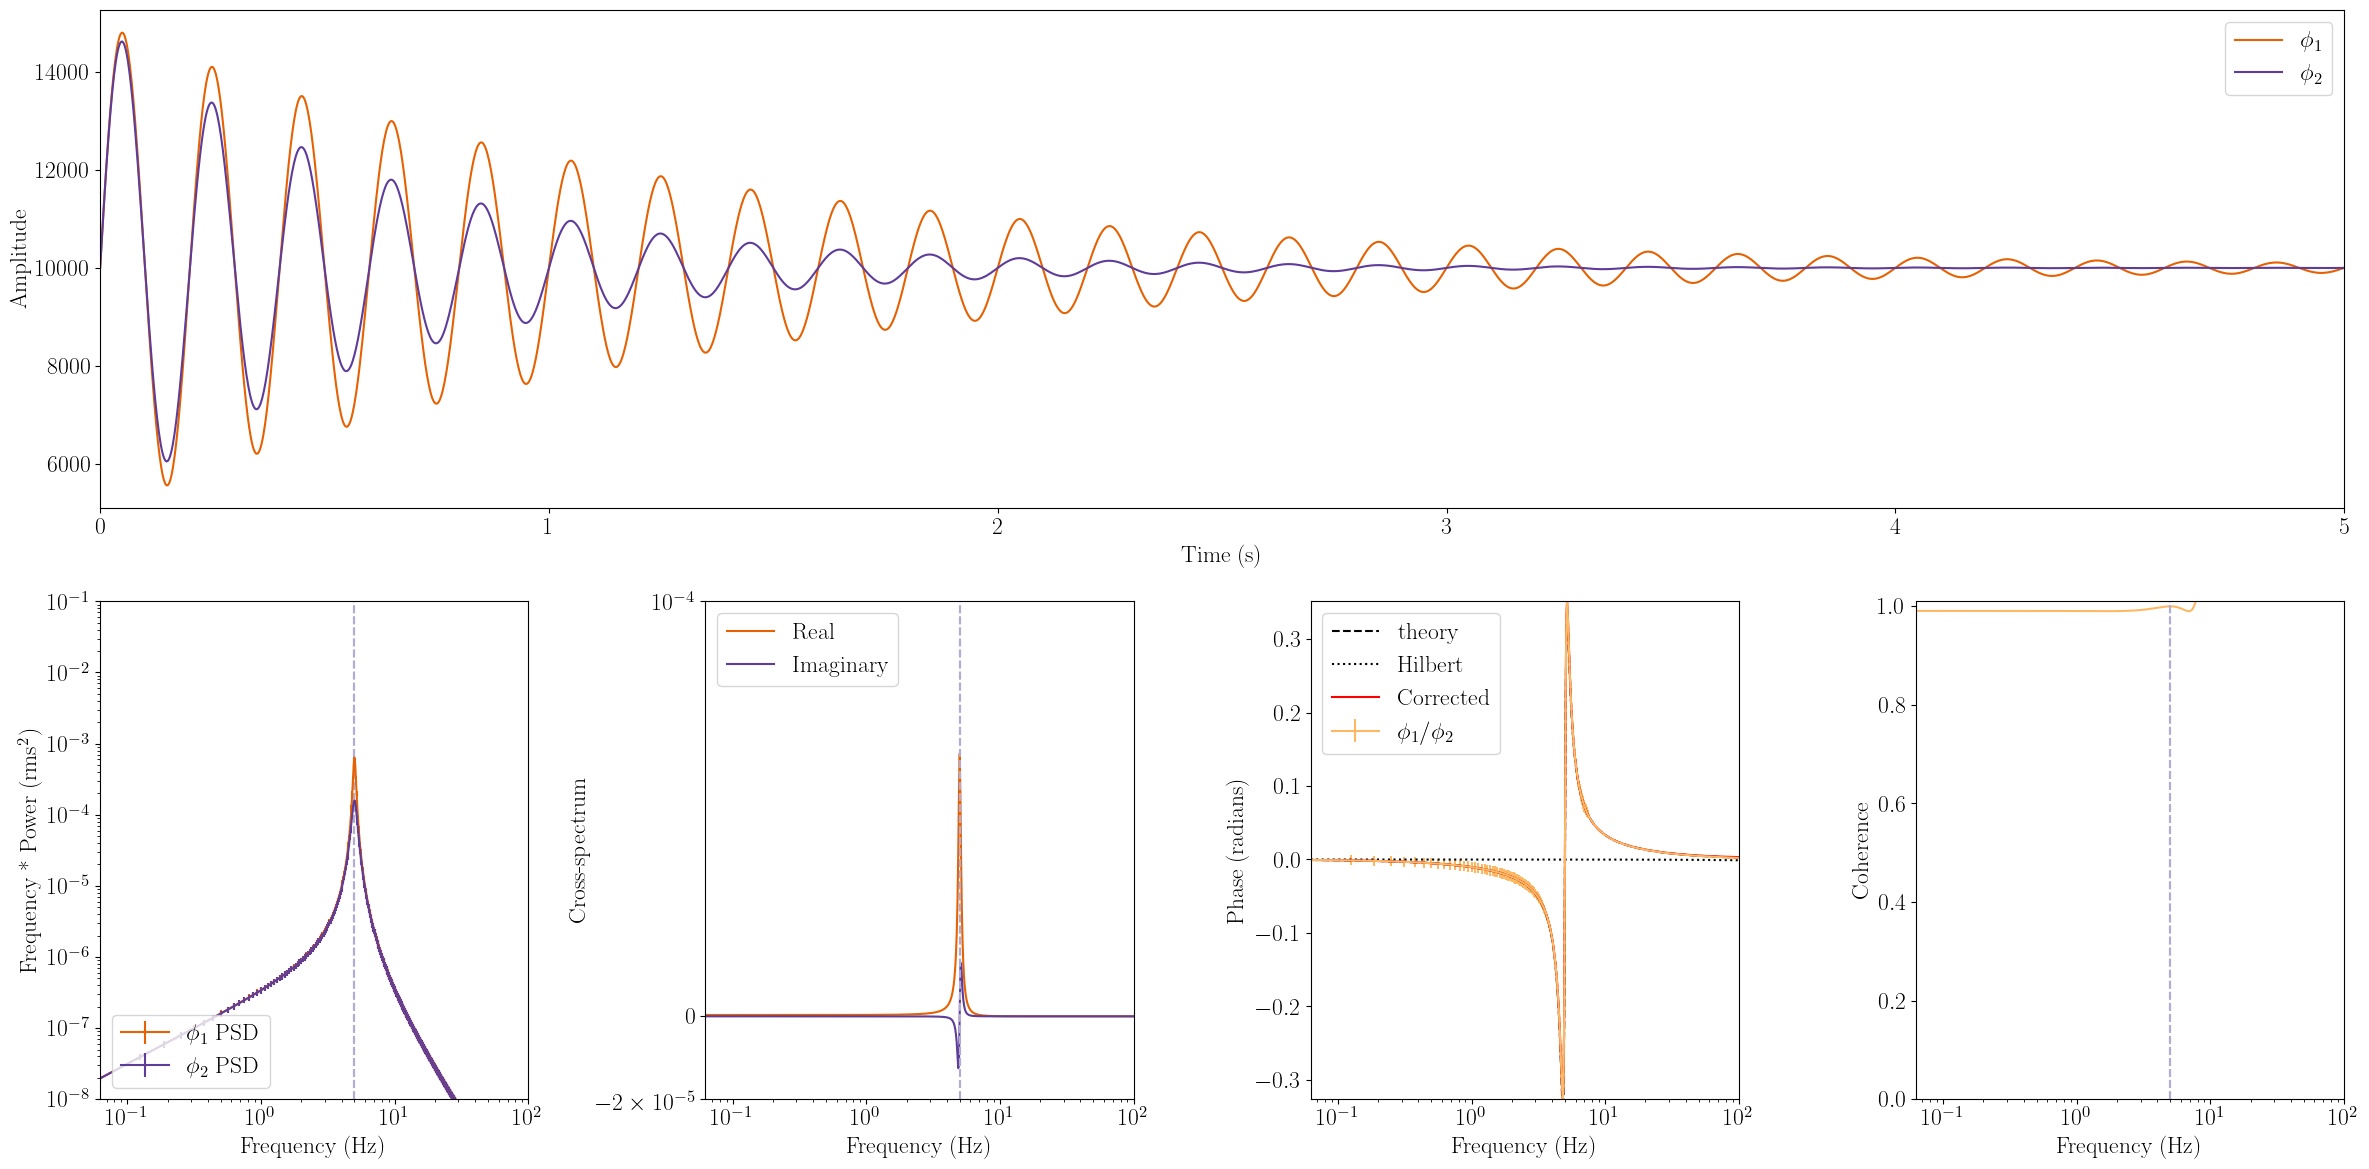

In [160]:
##
dt = 1/512
T = 16*100
index = int(T/dt)
t = np.arange(-T, T, dt)
t_plot = t[index:]

constant = 10000
omega1 = 5.0
omega2 = 5.0
dampen1 = 0.25
dampen2 = 0.5

x1 = make_decaying_sine(constant, 0.5, omega1, dampen1, 0, t)
x2 = make_decaying_sine(constant, 0.5, omega2, dampen2, 0, t)
#x3 = x1 + x2
x3 = sine_wave_distort(x1,x2,0.5)
lc1 = Lightcurve(t[index:], x1[index:])
lc2 = Lightcurve(t[index:], x2[index:])
x1_noise = lc1
x2_noise = lc2
#x1_noise.counts = gen_noise_original(lc1.time,lc1.counts,beta=0.1,norm=1000)
#x2_noise.counts = gen_noise_original(lc2.time,lc2.counts,beta=0.1,norm=1000)
#x1_noise.counts = np.random.poisson(x1_noise.counts)
#x2_noise.counts = np.random.poisson(x2_noise.counts)

ps1 = AveragedPowerspectrum.from_lightcurve(lc1, norm="frac",segment_size=16)
ps2 = AveragedPowerspectrum.from_lightcurve(lc2, norm="frac",segment_size=16)

cs12 = Crossspectrum.from_lightcurve(lc1, lc2, norm="frac")
avgcs12 = AveragedCrossspectrum.from_lightcurve(lc1, lc2, segment_size=16, norm="frac")


dampenx = dampen1
dampeny = dampen2

omegax = omega1
omegay = omega2

plot(t_plot,x1_noise,x2_noise,ps1,ps2,omega1,omega2,avgcs12,x_lim_lower=1/16,x_lim_upper=100,file="figures/simple_decaying_sine_wave.pdf",theory=True,hil=True)

# Wiggly sine wave

In [ ]:
def make_decaying_sine(constant, factor, nu, Dnu, phi, t, phase=0):
    """Decaying sine-wave"""
    alpha = np.pi * Dnu
    
    return constant + factor*constant*np.exp(-alpha * np.abs(t)) * np.sin(2*np.pi*nu*t - 2*np.pi*phi + phase)

# Poisson noise case

10it [00:00, 924.65it/s]
10it [00:00, 4880.50it/s]
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1766: UserWarning: n_ave is below 30. Please note that the error bars on the quantities derived from the cross spectrum are only reliable for a large number of averaged powers.
  warnings.warn(
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: divide by zero encountered in divide
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: invalid value encountered in sqrt
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
10it [00:00, 3603.66it/s]
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/utils.py:492: UserWarning: SIMON says: Number of segments used in averaging is significantly low. The result might not follow the expected statistical distributions.
  warnings.warn("SIMON says: {0}".format(message), **kwargs)
/o

[ 0.43547301 -0.33124963 -1.71623199 ...  0.23389434  2.92403612
 -2.86443995]
(4095,) (4095,) (4095,)
(4095,)
(4095,)


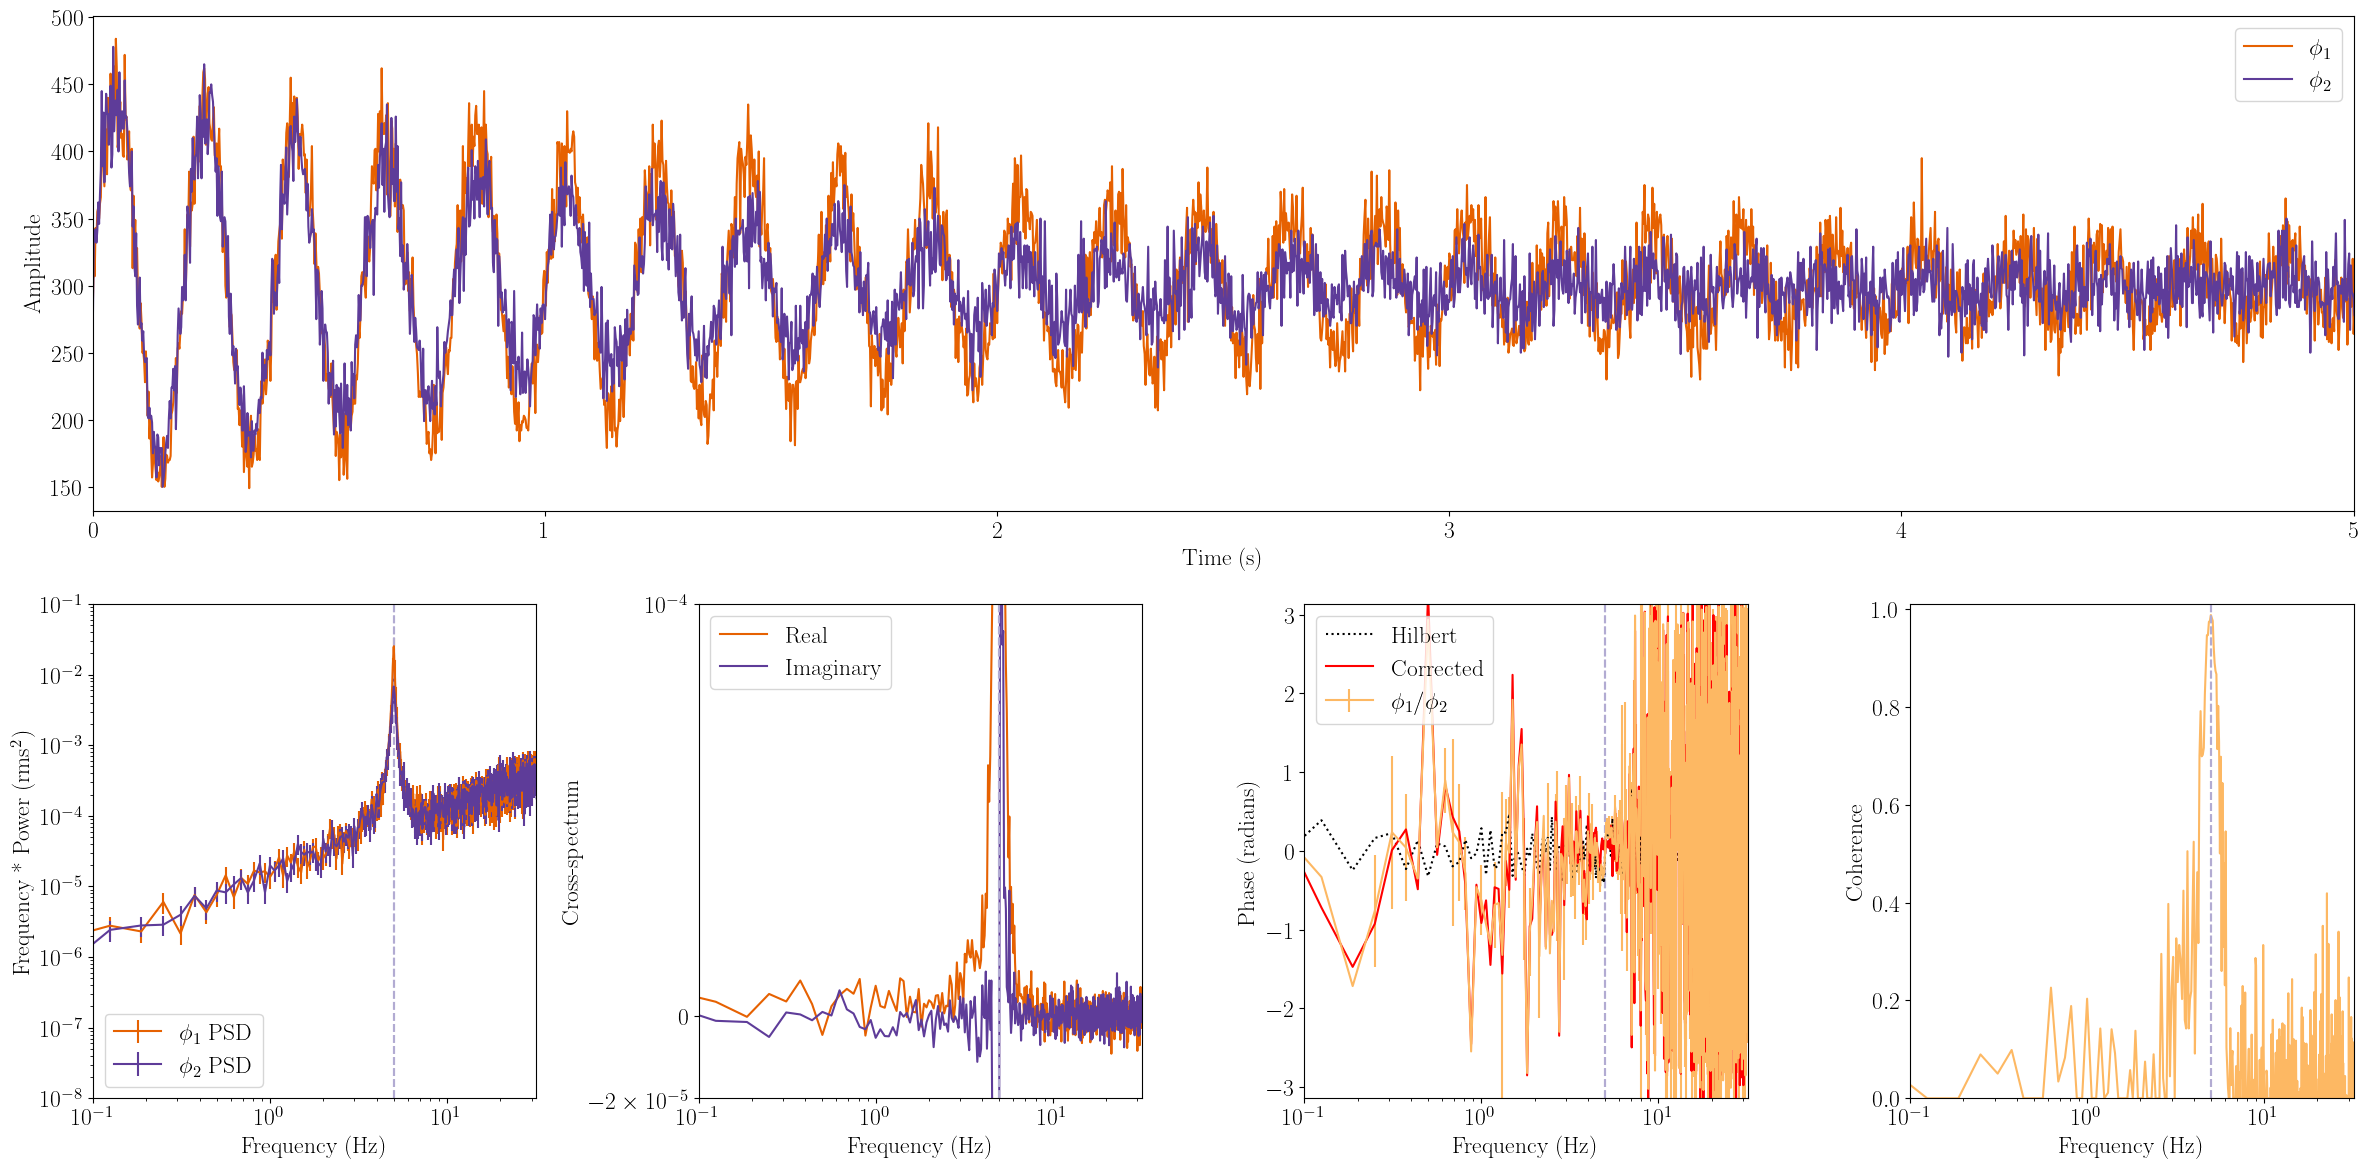

/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/utils.py:492: UserWarning: SIMON says: Number of segments used in averaging is significantly low. The result might not follow the expected statistical distributions.
  warnings.warn("SIMON says: {0}".format(message), **kwargs)
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:939: RuntimeWarning: invalid value encountered in divide
  uncertainty = (2**0.5 * coherence * (1 - coherence)) / (np.sqrt(coherence) * n_ave**0.5)


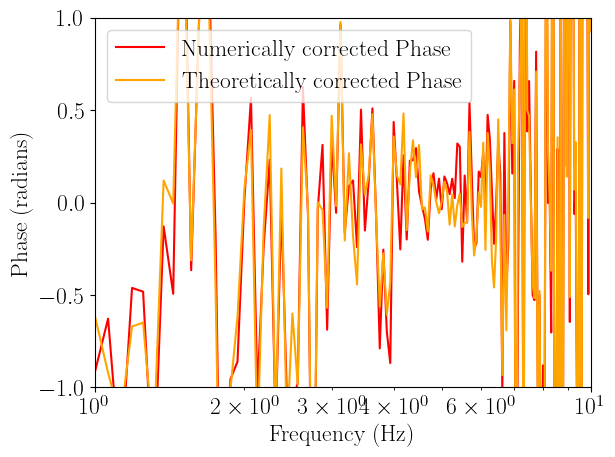

In [73]:
##
dt = 1/512
T = 16*10
index = int(T/dt)
t = np.arange(-T, T, dt)
t_plot = t[index:]

constant = 300
omega1 = 5.0
omega2 = 5.0
dampen1 = 0.25/2
dampen2 = 0.5/2

x1 = make_decaying_sine(constant, 0.5, omega1, dampen1, 0, t)
x2 = make_decaying_sine(constant, 0.5, omega2, dampen2, 0, t)
#x3 = x1 + x2
x3 = sine_wave_distort(x1,x2,0.5)
lc1 = Lightcurve(t[index:], x1[index:])
lc2 = Lightcurve(t[index:], x2[index:])
x1_noise = lc1
x2_noise = lc2
x1_noise.counts = np.random.poisson(x1_noise.counts)
x2_noise.counts = np.random.poisson(x2_noise.counts)

ps1 = AveragedPowerspectrum.from_lightcurve(lc1, norm="frac",segment_size=16)
ps2 = AveragedPowerspectrum.from_lightcurve(lc2, norm="frac",segment_size=16)

cs12 = Crossspectrum.from_lightcurve(lc1, lc2, norm="frac")
avgcs12 = AveragedCrossspectrum.from_lightcurve(lc1, lc2, segment_size=16, norm="frac")

plot(t_plot,x1_noise,x2_noise,ps1,ps2,omega1,omega2,avgcs12,x_lim_lower=0.1,x_lim_upper=32,hil=True)

plt.close()
coh = avgcs12.coherence()[0]
delta_theta = np.imag(hilbert(np.log(ps1.power/ps2.power)))/2
corrected_phase = np.angle(avgcs12.power) - delta_theta

numerator = (dampenx)*ps1.freq*(omegay**2 - ps1.freq**2) - (dampeny)*ps2.freq*(omegax**2 - ps2.freq**2)
denominator = (omega2**2-ps1.freq**2)*(omega1**2-ps1.freq**2) + (dampenx*dampeny)*(ps1.freq)**2
manual_delta_theta = np.arctan(numerator/denominator)

#plt.plot(avgcs12.freq, delta_theta, label="Hilbert", c="black", ls=":")
plt.plot(avgcs12.freq, avgcs12.phase_lag()[0] - delta_theta, label="Numerically corrected Phase", c="red")
plt.plot(avgcs12.freq, avgcs12.phase_lag()[0] - manual_delta_theta, label="Theoretically corrected Phase", c="orange")
#plt.plot(avgcs12.freq, avgcs12.phase_lag()[0], label="Original Phase")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (radians)")
plt.legend()
plt.xscale("log")
plt.xlim(1,10)
plt.ylim(-1,1)
plt.show()


10it [00:00, 7501.89it/s]
10it [00:00, 8386.93it/s]
10it [00:00, 5827.85it/s]
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1766: UserWarning: n_ave is below 30. Please note that the error bars on the quantities derived from the cross spectrum are only reliable for a large number of averaged powers.
  warnings.warn(
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: divide by zero encountered in divide
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))


[-0.09341758 -0.04040917  0.05349929 ...  1.42109419 -2.82789263
 -0.79935494]
(3999,) (3999,) (3999,)


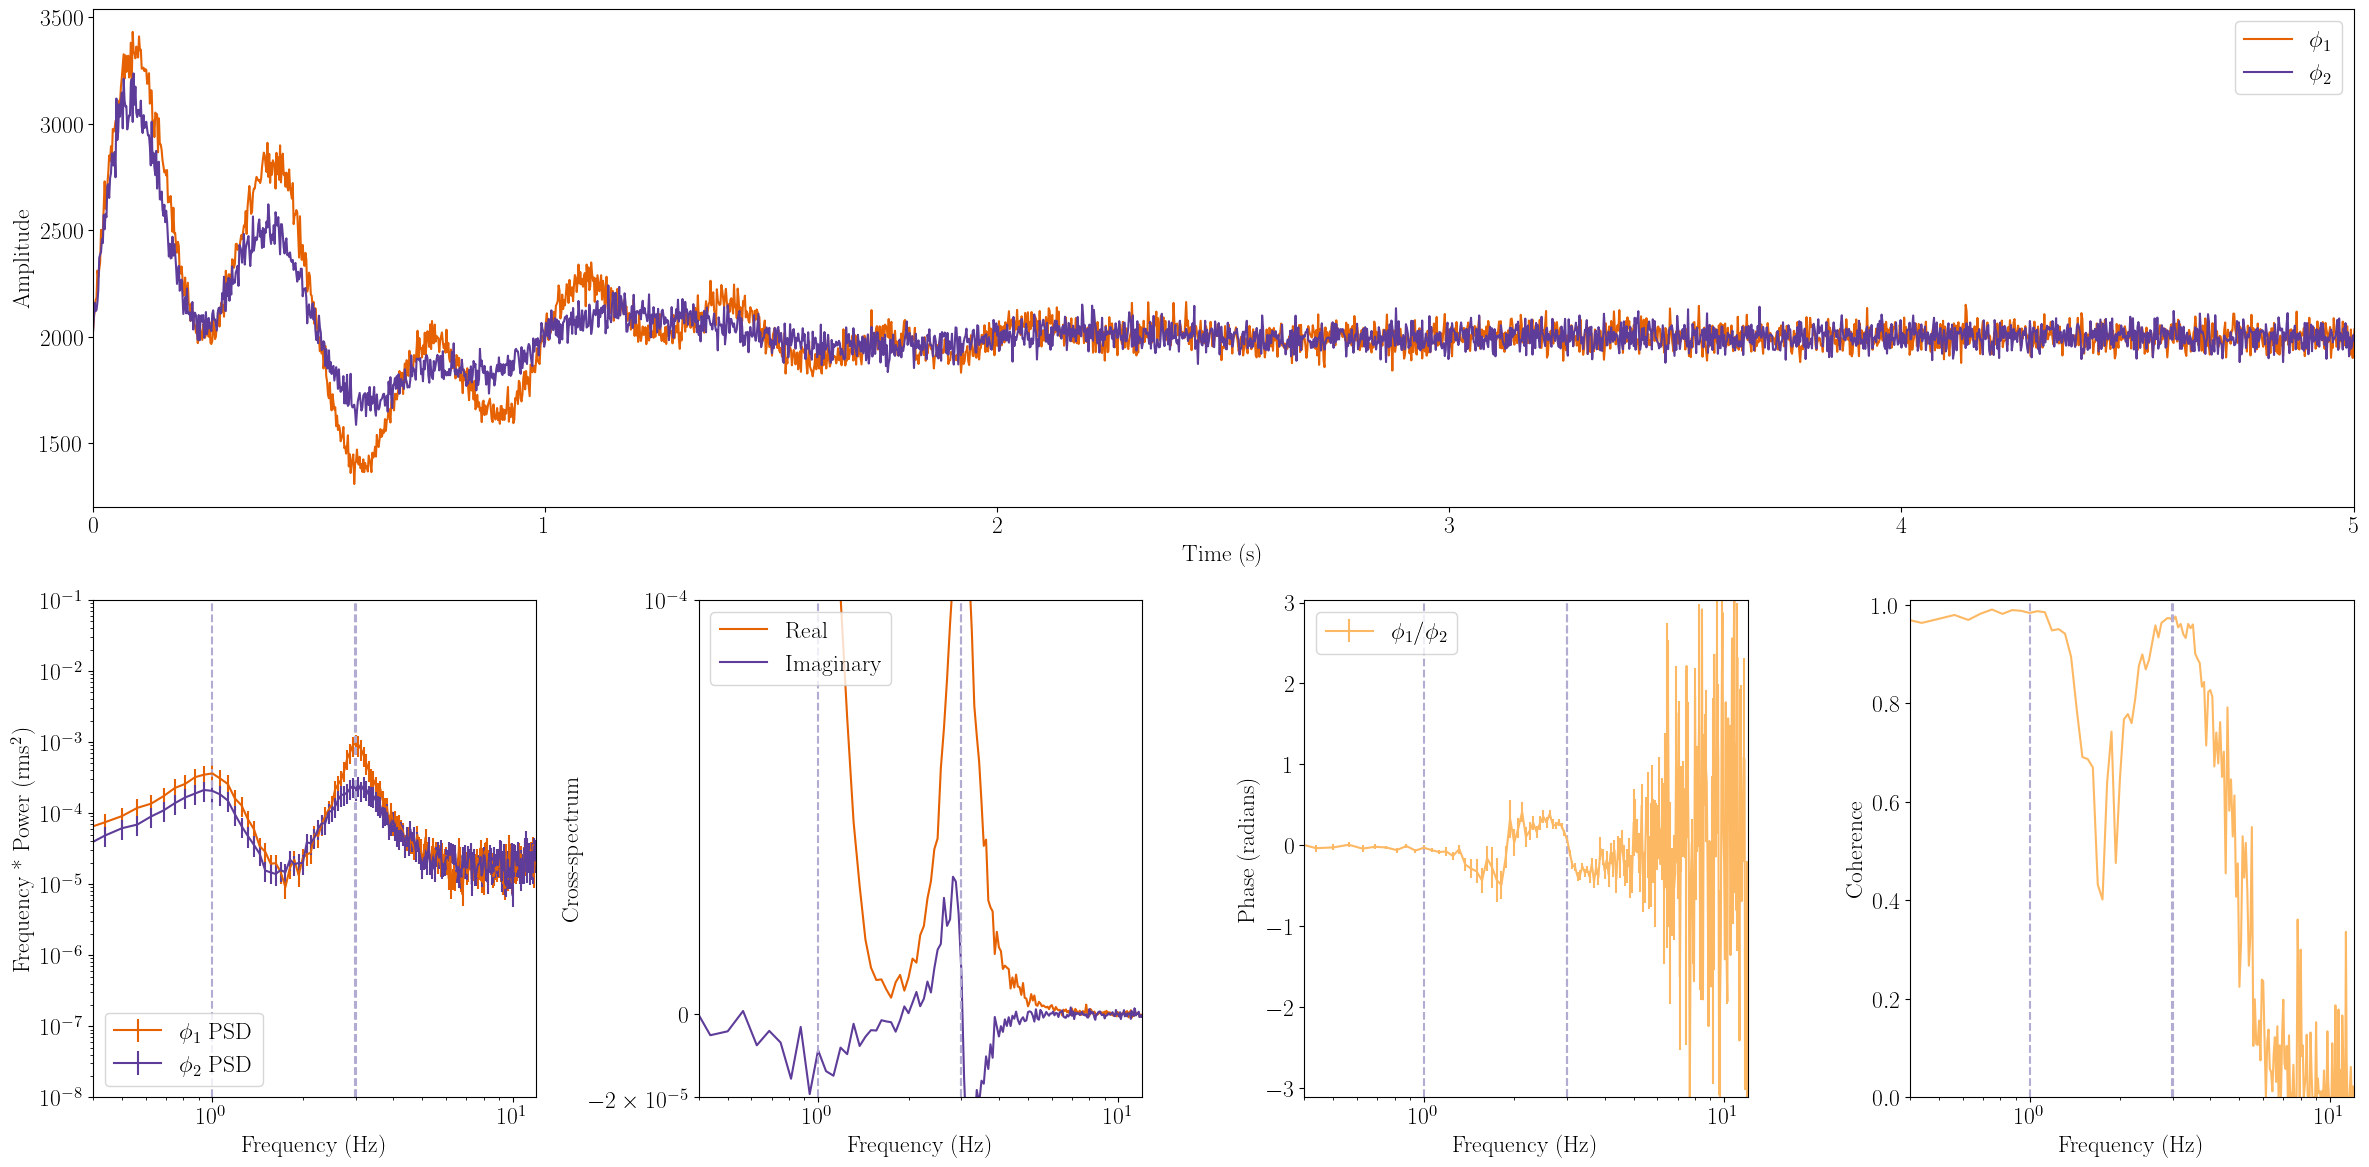

In [72]:
##
dt = 2e-3
T = 16*10
t = np.arange(0, T, dt)

constant = 1000
omega1 = 1.0
omega2 = 3.0
omega3 = 2.99
dampen1 = 0.5
dampen2 = 0.5
dampen3 = 1

x1 = make_decaying_sine(constant, 1, omega1, dampen1, 0, t)
x1_2 = make_decaying_sine(constant, 0.75, omega1, dampen1, 0, t)
x2 = make_decaying_sine(constant, 1, omega2, dampen2, 0, t)
x3 = make_decaying_sine(constant, 1, omega3, dampen3, 0, t)
lc1 = Lightcurve(t, x1)
lc1_2 = Lightcurve(t, x1_2)
lc2 = Lightcurve(t, x2)
lc3 = Lightcurve(t, x3)
x1_noise = lc1+lc2
x2_noise = lc1_2+lc3
x1_noise.counts = np.random.poisson(x1_noise.counts)
x2_noise.counts = np.random.poisson(x2_noise.counts)

ps1 = AveragedPowerspectrum.from_lightcurve(x1_noise, norm="frac", segment_size=16)
ps2 = AveragedPowerspectrum.from_lightcurve(x2_noise, norm="frac", segment_size=16)

avgcs12 = AveragedCrossspectrum.from_lightcurve(x2_noise, x1_noise, segment_size=16, norm="frac")

plot(t,x1_noise,x2_noise,ps1,ps2,omega1,omega2,avgcs12,x_lim_lower=0.4,x_lim_upper=12,file="figures/dual_signal.png",omega3=omega3)


# Broadband dual components

In [6]:
from scipy.signal import butter

def lorentz(freq,peak_f,q,rms):
    par_array = np.array([peak_f,q,rms])
    model = ndspec.Models.lorentz(freq,par_array)
    return model

def low_pass_ar_filter(signal, cutoff_fraction=0.01):
    """
    cutoff_fraction: Lower values = more high-frequency suppression.
    Try 0.05 to 0.01 to see the high-frequency Lorentzian drop.
    """
    # phi is the 'memory' coefficient
    phi = 1 - cutoff_fraction
    filtered = np.zeros_like(signal)
    
    # Simple recursive smoothing
    for i in range(1, len(signal)):
        filtered[i] = phi * filtered[i-1] + (1 - phi) * signal[i]
        
    return filtered

def butterworth_time_domain(signal, fs, cutoff, order=2):
    # 1. Get the Butterworth coefficients
    # 'fs' is your sampling frequency, 'cutoff' is where you want the drop to start
    b, a = butter(order, cutoff, fs=fs, btype='low')
    
    # 2. Initialize the output array
    y = np.zeros_like(signal)
    
    # 3. Apply the difference equation (Time Domain)
    # We start at index 2 because we need two previous values
    for n in range(2, len(signal)):
        y[n] = (b[0]*signal[n] + b[1]*signal[n-1] + b[2]*signal[n-2] 
                - a[1]*y[n-1] - a[2]*y[n-2])
        
    return y

def gaussian_filter(signal, sigma=1):
    """
    Applies a Gaussian filter to the input signal.

    Parameters
    ----------
    signal: array-like
        The input signal to which the Gaussian filter will be applied.
    sigma: float
        The standard deviation of the Gaussian kernel.

    Returns
    -------
    filtered: array-like
        The filtered signal.
    """
    # Create a Gaussian kernel
    kernel = np.exp(-0.5 * (np.arange(-3*sigma, 3*sigma+1) / sigma)**2)
    kernel /= np.sum(kernel)

    # Apply the Gaussian filter using convolution
    filtered = np.convolve(signal, kernel, mode='same')
    return filtered

def resonant_filter(signal, fs, target_freq, Q, gain=1.0):
    """
    Transforms a lightcurve by shifting its Lorentzian peak.
    
    fs: Sampling frequency (Hz)
    target_freq: Where you want the RED peak to be (Hz)
    Q: Quality factor (lower = wider/worse Q)
    gain: Vertical scaling (to drop the PSD height)
    """
    n = len(signal)
    filtered = np.zeros(n)
    
    # 1. Calculate the Bandwidth from Q
    # As Q gets smaller, the bandwidth (bw) gets larger, smearing the signal.
    bw = target_freq / Q
    
    # 2. Determine the Pole Radius (R) and Angle (theta)
    # R determines how "sharp" the peak is.
    R = np.exp(-np.pi * bw / fs)
    theta = 2 * np.pi * target_freq / fs
    
    # 3. Filter Coefficients
    a1 = 2 * R * np.cos(theta)
    a2 = -R**2
    # Normalization factor to keep the gain in check
    b0 = (1 - R**2) * gain 
    
    # 4. Difference Equation (The Time-Domain Loop)
    for i in range(2, n):
        filtered[i] = (a1 * filtered[i-1] + 
                       a2 * filtered[i-2] + 
                       b0 * signal[i])
        
    return filtered

def frequency_up_conversion(t, x, fshift):
    """
    Upsamples the input signal by a factor of 2 using zero-order hold.

    Parameters
    ----------
    t : array-like
        The time array corresponding to the input signal.
    x : array-like
        The input signal to be upsampled.
    fshift : float
        Frequency shift.

    Returns
    -------
    upsampled : array-like
        The upsampled signal.
    """
    y = x * np.cos(2 * np.pi * fshift * t)
    #y = low_pass_ar_filter(y)
    return y

def timmer_koenig(x, mean, dt, omega1, omega2, q1, q2, rms1, rms2):
    rms = rms1 + rms2
    sim = simulator.Simulator(N=len(x), mean=mean, dt=dt, rms=rms, poisson=True)
    w = np.fft.rfftfreq(sim.N, d=sim.dt)[1:]
    lorentz1 = lorentz(w,omega1,q1,rms1)
    lorentz2 = lorentz(w,omega2,q2,rms2)
    psd_array = lorentz1 + lorentz2
    psd_err = np.sqrt(psd_array)
    lc1 = sim.simulate(lorentz1)
    lc2 = sim.simulate(lorentz2)
    return lc1, lc2, w, lorentz1, lorentz2, psd_array, psd_err

def plot_2(t_plot,x1_noise,x2_noise,ps1,ps2,avgcs12,x_lim_lower=None,x_lim_upper=None,omega1=None,omega2=None,
           lorentz1=None,lorentz2=None):
    """
    Plots results

    Parameters
    -----------
    t_plot : array
        Time array for the plot.
    x1_noise : Lightcurve
        Lightcurve object for the first signal with noise.
    x2_noise : Lightcurve
        Lightcurve object for the second signal with noise.
    ps1 : Powerspectrum
        Power spectrum object for the first signal.
    ps2 : Powerspectrum
        Power spectrum object for the second signal.
    omega1 : float
        Frequency of the first signal.
    omega2 : float
        Frequency of the second signal.
    cs12 : Crossspectrum
        Cross spectrum object between the two signals.
    avgcs12 : AveragedCrossspectrum
        Averaged cross spectrum object between the two signals.
    x_lim_lower : float
        Lower limit for the x-axis.
    x_lim_upper : float
        Upper limit for the x-axis.

    """
    fig = plt.figure(figsize=(16, 6))

    ax2=plt.subplot(1,4,1)
    ax2.errorbar(ps1.freq, ps1.freq*ps1.power, yerr=ps1.freq*ps1.power_err, c="#e66101",label=r"$\phi_1$")
    ax2.errorbar(ps2.freq, ps2.freq*ps2.power, yerr=ps2.freq*ps2.power_err, c="#5e3c99",label=r"$\phi_2$")
    if omega1 is not None:
        ax2.axvline(omega1, color="#b2abd2", linestyle='--',label=r"$\omega_1$")
    if omega2 is not None:
        ax2.axvline(omega2, color="#b2abd2", linestyle='--',label=r"$\omega_2$")
    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.legend()
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel(r"Frequency * Power (rms$^2$)")
    ax2.set_ylim(5e-5, 1e-1)
    ax2.set_xlim(x_lim_lower, x_lim_upper)

    ax3=plt.subplot(1,4,2)
    ax3.plot(avgcs12.freq, np.real(avgcs12.power), c="#e66101",label="Real")
    ax3.plot(avgcs12.freq, np.imag(avgcs12.power), c="#5e3c99",label="Imaginary")
    if omega1 is not None:
        ax3.axvline(omega1, color="#b2abd2", linestyle='--',label=r"$\omega_1$")
    if omega2 is not None:
        ax3.axvline(omega2, color="#b2abd2", linestyle='--',label=r"$\omega_2$")
    ax3.set_yscale('symlog',linthresh=1e-4)
    ax3.set_xscale("log")
    ax3.set_ylabel('Cross-spectrum')
    ax3.legend()
    #ax3.set_ylim(-1e5, 1e6)
    ax3.set_xlim(x_lim_lower, x_lim_upper)
    ax3.set_xlabel("Frequency (Hz)")

    ax4 = plt.subplot(1,4,3)
    ax4.plot(avgcs12.freq, np.angle(avgcs12.power), c="#fdb863", label=r"$\phi_1/\phi_2$")
    if omega1 is not None:
        ax4.axvline(omega1, color="#b2abd2", linestyle='--',label=r"$\omega_1$")
    if omega2 is not None:
        ax4.axvline(omega2, color="#b2abd2", linestyle='--',label=r"$\omega_2$")

    ax4.set_xscale("log")
    ax4.set_ylabel('Phase (radians)')
    #ax4.set_ylim(-np.pi, np.pi)
    ax4.set_xlabel("Frequency (Hz)")
    ax4.set_xlim(x_lim_lower, x_lim_upper)
    ax4.legend()

    ax5 = plt.subplot(1,4,4)
    ax5.plot(avgcs12.freq, avgcs12.coherence(), c="#fdb863", label=r"$\phi_1/\phi_2$")
    if omega1 is not None:
        ax5.axvline(omega1, color="#b2abd2", linestyle='--',label=r"$\omega_1$")
    if omega2 is not None:
        ax5.axvline(omega2, color="#b2abd2", linestyle='--',label=r"$\omega_2$")
    ax5.set_xscale("log")
    ax5.set_ylabel('Coherence')
    ax5.set_xlabel("Frequency (Hz)")
    ax5.set_ylim(0.8, 1.01)
    ax5.set_xlim(x_lim_lower, x_lim_upper)
    ax5.legend()

    plt.tight_layout()
    plt.savefig("figures/broadband.png")
    plt.show()

In [ ]:
dt = 2e-3
T = 16*50
t = np.arange(0, T, dt)

lc1, lc2, w, lorentz1, lorentz2, psd_array1, psd_err = timmer_koenig(t, mean=500, dt=dt, omega1=0.5, omega2=2.0, q1=1e-1, q2=1e-1, rms1=0.18, rms2=0.1)
lc3, lc4, w, lorentz3, lorentz4, psd_array2, psd_err = timmer_koenig(t, mean=500, dt=dt, omega1=0.5, omega2=3.0, q1=1e-1, q2=1e-1, rms1=0.3*0.9, rms2=0.27*0.9)

plt.plot(w, w*psd_array1, label= "Total 1+2", c="blue")
plt.plot(w, w*lorentz1, label= "Lorentz 1", ls="--", c="blue")
plt.plot(w, w*lorentz2, label= "Lorentz 2", ls="--", c="blue")
plt.plot(w, w*psd_array2, label= "Total 3+4", c="green")
plt.plot(w, w*lorentz3, label= "Lorentz 3", ls="--", c="green")
plt.plot(w, w*lorentz4, label= "Lorentz 4", ls="--", c="green")
plt.loglog()
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"Frequency * Power (rms$^2$)")
plt.xlim(0.05,13)
plt.ylim(3e-4,5e-2)
plt.show()
plt.close()
"""
x1 = gaussian_filter(lc1.counts, sigma=100)
x2 = gaussian_filter(lc2.counts, sigma=100)
x3 = gaussian_filter(lc1.counts + lc2.counts, sigma=100)
print(type(x3))
lc3 = Lightcurve(t, x3)

x4 = butterworth_time_domain(lc2.counts, fs=1.5, cutoff=0.1,order=2)
print(type(x4))
x4[x4 < 0] = 0
lc4 = Lightcurve(t, x4)

x5 = resonant_filter(lc2.counts, fs=3, target_freq=1.5, Q=2, gain=10)
x5[x5 < 0] = 0
print(type(x5))
lc5 = Lightcurve(t, x5)

x6 = frequency_up_conversion(t, lc2.counts, fshift=1.5)
x6[x6 < 0] = 0
lc6 = Lightcurve(t, x6)
"""

lc12 = lc1 + lc2
lc13 = lc3 + lc4

ps1 = AveragedPowerspectrum.from_lightcurve(lc12, norm="frac",segment_size=16)
ps2 = AveragedPowerspectrum.from_lightcurve(lc13, norm="frac",segment_size=16)

cs12 = Crossspectrum.from_lightcurve(lc12, lc13, norm="frac")
avgcs12 = AveragedCrossspectrum.from_lightcurve(lc12, lc13, segment_size=16, norm="frac")

plot_2(t,lc12,lc13,ps1,ps2,avgcs12,x_lim_lower=1/16,x_lim_upper=15,omega1=3,omega2=0.5)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_sos_signal(t, psd, freqs, N, fudge=1.0):
    # 2. Cumulative Power (Integration)
    cum_power = np.cumsum(psd) * (freqs[1] - freqs[0])
    total_power = cum_power[-1]
    
    # 3. Equal-Area Discretization
    # We find frequencies that split the total power into N equal chunks
    target_levels = np.linspace(0, total_power, N + 1)
    chosen_freqs = []
    for i in range(N):
        # Find frequency where cumulative power hits the midpoint of the chunk
        midpoint = (target_levels[i] + target_levels[i+1]) / 2
        idx = np.argmin(np.abs(cum_power - midpoint))
        chosen_freqs.append(freqs[idx])
        
    # 4. Synthesize Signal
    # Amplitude for equal-area: A = sqrt(2 * total_power / N)
    amp = np.sqrt(2 * total_power / N) / fudge
    signal = np.zeros_like(t)
    alpha = 0.1
    for f in chosen_freqs:
        signal += amp * np.cos(2 * np.pi * f * t) * np.exp(-alpha * np.abs(t))

    return t, signal, chosen_freqs

dt = 2e-3
T = 16*100
t = np.arange(0, T, dt)

lc1, lc2, w, lorentz1, lorentz2, psd_array1, psd_err = timmer_koenig(t, mean=500, dt=dt, omega1=0.5, omega2=2.0, q1=1e-1, q2=1e-1, rms1=0.18, rms2=0.1)
lc3, lc4, w, lorentz3, lorentz4, psd_array2, psd_err = timmer_koenig(t, mean=500, dt=dt, omega1=0.5, omega2=3.0, q1=1e-1, q2=1e-1, rms1=0.3*0.9, rms2=0.4)

# Parameters
N_waves = 5000  # Try 15 vs 100 to see the difference
t, sig, f_list = generate_sos_signal(t, lorentz1+lorentz2, w, N_waves, 0.9)
sig = constant*sig + constant
#sig[sig < 0] = 0
#sig = np.random.poisson(sig)
lc_approx = Lightcurve(t,sig)
print(f"Approximated using only {len(f_list)} sine waves.")

t2, sig2, f_list2 = generate_sos_signal(t, lorentz3+lorentz4, w, N_waves,0.6)
sig2 = constant*sig2 + constant
#sig2[sig2 < 0] = 0
#sig2 = np.random.poisson(sig2)
lc_approx2 = Lightcurve(t2,sig2)
print(f"Approximated using only {len(f_list2)} sine waves.")

In [ ]:
ps1 = AveragedPowerspectrum.from_lightcurve(lc_approx, norm="frac",segment_size=16)
ps2 = AveragedPowerspectrum.from_lightcurve(lc_approx2, norm="frac",segment_size=16)

plt.plot(ps1.freq, ps1.freq*ps1.power, 'k-',label=r"Approximated PSD 1")
plt.plot(ps2.freq, ps2.freq*ps2.power, 'r-',label=r"Approximated PSD 2")
plt.plot(w, w*(lorentz1+lorentz2), 'b--',label=r"Model 1")
plt.plot(w, w*(lorentz3+lorentz4), 'g--',label=r"Model 2")
plt.xlabel("Frequency")
plt.ylabel("Frequency * Power")
plt.loglog()
plt.legend()
plt.show()

In [ ]:
cs12 = Crossspectrum.from_lightcurve(lc_approx, lc_approx2, norm="frac")
avgcs12 = AveragedCrossspectrum.from_lightcurve(lc_approx, lc_approx2, segment_size=16, norm="frac")

plot_2(t,lc_approx,lc_approx2,ps1,ps2,avgcs12,x_lim_lower=1/16,x_lim_upper=15,omega1=3,omega2=0.5)

# Demonstration of no phase lag in only rms magnitude change case

In [ ]:
lc1, lc2, w, lorentz1, lorentz2, psd_array1, psd_err = timmer_koenig(t, mean=500, dt=dt, omega1=0.5, omega2=2.0, q1=1e-1, q2=1e-1, rms1=0.18, rms2=0.1)

In [ ]:
ps1 = AveragedPowerspectrum.from_lightcurve(lc2, norm="frac",segment_size=16)
lc2.counts += 1000

In [ ]:
ps1_post_constant = AveragedPowerspectrum.from_lightcurve(lc2, norm="frac",segment_size=16)

In [ ]:
plt.plot(ps1.freq, ps1.freq*ps1.power, 'k-',label=r"Original PSD")
plt.plot(ps1_post_constant.freq, ps1_post_constant.freq*ps1_post_constant.power, 'r-',label=r"Post-Constant PSD")
plt.xlabel("Frequency")
plt.ylabel("Frequency * Power")
plt.legend()
plt.loglog()

In [ ]:
cs12 = AveragedCrossspectrum.from_lightcurve(lc1, lc2, norm="frac")
print(cs12.power.mean())

plt.plot(cs12.freq, np.angle(cs12.power), 'k-',label=r"Original CSD")
plt.xlabel("Frequency")
plt.ylabel("Phase")
plt.legend()
plt.show()
plt.close()

plt.plot(cs12.freq, cs12.coherence(), 'k-',label=r"Original CSD")
plt.xlabel("Frequency")
plt.ylabel("Coherence")
plt.ylim(0,1.01)
plt.legend()
plt.show()
plt.close()

# Narrow QPO rms change

In [ ]:
dt = 2e-3
T = 16*50
t = np.arange(0, T, dt)

lc1, lc2, w, lorentz1, lorentz2, psd_array1, psd_err = timmer_koenig(t, mean=500, dt=dt, omega1=0.5, omega2=2.0, q1=1e-1, q2=5, rms1=0.3, rms2=0.1)
lc3, lc4, w, lorentz3, lorentz4, psd_array2, psd_err = timmer_koenig(t, mean=500, dt=dt, omega1=0.5, omega2=2.0, q1=1e-1, q2=5, rms1=0.3, rms2=0.3)

plt.plot(w, w*psd_array1, label= "Total 1+2", c="blue")
plt.plot(w, w*lorentz1, label= "Lorentz 1", ls="--", c="blue")
plt.plot(w, w*lorentz2, label= "Lorentz 2", ls="--", c="blue")
plt.plot(w, w*psd_array2, label= "Total 3+4", c="green")
plt.plot(w, w*lorentz3, label= "Lorentz 3", ls="--", c="green")
plt.plot(w, w*lorentz4, label= "Lorentz 4", ls="--", c="green")
plt.loglog()
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"Frequency * Power (rms$^2$)")
plt.xlim(0.05,13)
plt.ylim(3e-4,1e0)
plt.show()
plt.close()

In [ ]:
def timmer_koenig_single(x, mean, dt, omega, q, rms):
    sim = simulator.Simulator(N=len(x), mean=mean, dt=dt, rms=rms, poisson=True)
    w = np.fft.rfftfreq(sim.N, d=sim.dt)[1:]
    lor = lorentz(w,omega,q,rms)
    psd_array = lor
    psd_err = np.sqrt(psd_array)
    lc = sim.simulate(lor)
    return lc, w, lor, psd_array, psd_err

In [ ]:
import copy

lc1, w, lorentz1, psd_array1, psd_err = timmer_koenig_single(t, mean=500, dt=dt, omega=0.5, q=1e-1, rms=0.3)
original_lc_mean = lc1.counts.mean()
original_lc_scale = lc1.counts - original_lc_mean
lc3 = copy.deepcopy(lc1)
lc3.counts = 20*(lc3.counts - original_lc_mean) + 10000

lc2, w, lorentz2, psd_array2, psd_err = timmer_koenig_single(t, mean=500, dt=dt, omega=2.0, q=5, rms=0.3)
original_lc_mean = lc2.counts.mean()
original_lc_scale = lc2.counts - original_lc_mean
#lc2.counts = 10*(lc2.counts - original_lc_mean) + 10000
lc4 = copy.deepcopy(lc2)
lc4.counts = 10*(lc4.counts - original_lc_mean) + 10000

ps1 = AveragedPowerspectrum.from_lightcurve(lc1, norm="frac",segment_size=16)
ps2 = AveragedPowerspectrum.from_lightcurve(lc2, norm="frac",segment_size=16)

ps3 = AveragedPowerspectrum.from_lightcurve(lc1+lc2, norm="frac",segment_size=16)
ps4 = AveragedPowerspectrum.from_lightcurve(lc3+lc4, norm="frac",segment_size=16)

plt.plot(w, w*lorentz1, label= "Lorentz 1", ls="--", c="blue")
plt.plot(w, w*lorentz2, label= "Lorentz 2", ls="--", c="green")
plt.plot(w, w*lorentz1 + w*lorentz2, label= "Total", c="blue")
plt.errorbar(ps3.freq, ps3.freq*ps3.power, yerr=ps3.freq*ps3.power_err, label="Calculated Total", c="purple")
plt.errorbar(ps4.freq, ps4.freq*ps4.power, yerr=ps4.freq*ps4.power_err, label="Calculated Total changed", c="pink")
plt.loglog()
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"Frequency * Power (rms$^2$)")
plt.xlim(0.05,13)
#plt.ylim(3e-4,1e0)
plt.show()
plt.close()

cs12 = Crossspectrum.from_lightcurve(lc1+lc2, lc3+lc4, norm="frac")
plot_2(t,lc1+lc2,lc3+lc4,ps3,ps4,cs12,x_lim_lower=1/16,x_lim_upper=15,omega1=2,omega2=None)

# How can we model away the problem?

Obviously this presents an issue. How can we actually do spectral timing practically speaking if this is going to crop up as an issue? In principle, if you know that signal X is related by a transfer function $H(f)$ to signal Y such that:

$S_{xy}(f) = H(f) * S_{xx}(f)$

and 

$S_{yy}(f) = \left|{H(f)}\right|^2 \cdot S_{xx}(f)$

# Non-minimum phase transfer functions

One possible way to get a non-linear extra phase change is non-minimum phase transfer functions. Let's try a couple out.

In [ ]:
import numpy as np

def delay_tf(freqs, tau):
    """Pure time delay by tau seconds."""
    omega = 2 * np.pi * freqs
    return np.exp(-1j * omega * tau)

def allpass_tf(freqs, omega_z, gamma_z):
    """
    All-pass filter: non-minimum-phase zero paired with
    conjugate pole, both with the same real part omega_z
    and imaginary part ±gamma_z/2.
    """
    omega = 2 * np.pi * freqs
    z = omega_z + 1j * gamma_z / 2       # upper half-plane
    z_conj = omega_z - 1j * gamma_z / 2  # lower half-plane
    return (omega - z_conj) / (omega - z)

def echo_tf(freqs, alpha, tau):
    """
    Direct signal plus one delayed echo with amplitude alpha.
    For |alpha| < 1 and real alpha, the zeros lie in different
    half-planes depending on the sign.
    """
    omega = 2 * np.pi * freqs
    return 1 + alpha * np.exp(-1j * omega * tau)

def coupled_oscillators_tf(freqs, omega1, gamma1, omega2, gamma2, 
                            kappa, zero_type='minimum'):
    """
    Two coupled damped oscillators.
    zero_type: 'minimum' (zero in LHP) or 'nonminimum' (zero in UHP)
    """
    omega = 2 * np.pi * freqs
    
    # Denominator: two resonances with coupling
    denom1 = omega1**2 - omega**2 + 1j * gamma1 * omega
    denom2 = omega2**2 - omega**2 + 1j * gamma2 * omega
    denom = denom1 * denom2 - kappa**2
    
    # Numerator zero location
    omega_z = (omega1 + omega2) / 2
    gamma_z = (gamma1 + gamma2) / 2
    
    if zero_type == 'minimum':
        # Zero in lower half-plane
        numer = omega_z**2 - omega**2 + 1j * gamma_z * omega
    else:
        # Zero in upper half-plane (flip sign of imaginary part)
        numer = omega_z**2 - omega**2 - 1j * gamma_z * omega
    
    return numer / denom

def feedback_tf(freqs, wp_fwd, wz_fwd, k_fwd, wp_fb, k_fb):
    """
    Feedback system with a forward path G(s) = k_fwd * (s + wz_fwd) / (s + wp_fwd)
    and feedback F(s) = k_fb / (s + wp_fb).
    Depending on parameters, closed-loop zeros can be in UHP.
    """
    s = 1j * 2 * np.pi * freqs  # s = j*omega
    
    G = k_fwd * (s + wz_fwd) / (s + wp_fwd)
    F = k_fb / (s + wp_fb)
    
    return G / (1 + G * F)

def damped_oscillator(freqs, omega_0, gamma):
    """Minimum-phase damped oscillator transfer function."""
    omega = 2 * np.pi * freqs
    return 1.0 / (omega_0**2 - omega**2 + 1j * gamma * omega)

def sum_of_oscillators_tf(freqs, params_list, amplitudes):
    """
    Sum of damped oscillators.
    
    params_list: list of (omega_0, gamma) tuples
    amplitudes: complex amplitudes for each oscillator
    
    The total can be non-minimum-phase even if each component isn't.
    """
    H_total = np.zeros(len(freqs), dtype=complex)
    for (omega_0, gamma), a in zip(params_list, amplitudes):
        H_total += a * damped_oscillator(freqs, omega_0, gamma)
    return H_total

In [161]:
import numpy as np
from scipy.signal import fftconvolve

def frequency_to_impulse_response(freqs, H_func, t_max, dt, **tf_kwargs):
    """
    Convert a frequency-domain transfer function to an impulse
    response in the time domain.
    
    freqs, H_func: the transfer function as a function of frequency
    t_max: maximum time for the impulse response
    dt: time step
    """
    # Build a uniform frequency grid suitable for FFT
    N = int(t_max / dt)
    if N % 2 == 1:
        N += 1
    
    # FFT frequencies: from -f_nyquist to +f_nyquist
    f_fft = np.fft.fftfreq(N, d=dt)
    
    # Evaluate transfer function at FFT frequencies
    # (most TF functions expect positive freqs, so we use abs
    #  and handle the Hermitian symmetry for real impulse response)
    H_fft = np.zeros(N, dtype=complex)
    
    # Positive frequencies
    pos_mask = f_fft > 0
    H_fft[pos_mask] = H_func(f_fft[pos_mask], **tf_kwargs)
    
    # Negative frequencies by Hermitian symmetry for real h(t)
    neg_mask = f_fft < 0
    H_fft[neg_mask] = np.conj(H_func(-f_fft[neg_mask], **tf_kwargs))
    
    # DC component
    H_fft[0] = np.real(H_func(np.array([1e-10]), **tf_kwargs)[0])
    
    # Inverse FFT to get impulse response
    h = np.real(np.fft.ifft(H_fft)) / dt  # normalize by dt
    t = np.arange(N) * dt
    
    return t, h

def apply_transfer_function(input_signal, h, dt):
    """Apply impulse response to input signal via convolution."""
    output = fftconvolve(input_signal, h, mode='full') * dt
    # Trim to match input length
    return output[:len(input_signal)]

In [200]:
dt = 1/512
mean = 100
T = 1024/dt
rms = 0.5

sim = simulator.Simulator(N=int(T), mean=mean, dt=dt, rms=rms, poisson=True)
w = np.fft.rfftfreq(sim.N, d=sim.dt)[1:]
lc1 = sim.simulate(2)

t, h = frequency_to_impulse_response(w, delay_tf, t_max=100, dt=0.01, tau=0.05)

out = apply_transfer_function(lc1.counts, h, dt)
out = Lightcurve(lc1.time, out)

/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/simulator/simulator.py:390: UserWarning: Some bins of the light curve have counts < 0. Setting to 0
  warnings.warn("Some bins of the light curve have counts < 0. Setting to 0")


In [320]:
def plot_result(lc1,lc2,t,h):
    """
    Plot the results of the light curve simulation.
    """
    fig = plt.figure(figsize=(12, 8))

    ax1 = plt.subplot(2, 2, 1)

    ax1.plot(lc1.time, lc1.counts, label="Original")
    ax1.plot(lc2.time, lc2.counts, label="Transfer functioned")
    ax1.set_xlabel("Times (s)")
    ax1.set_ylabel("Amplitude")
    ax1.legend()

    ax2 = plt.subplot(2, 2, 2)
    ax2.plot(t, h, label="Impulse Response")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Amplitude")
    ax2.legend()
    ax2.loglog()
    ax2.set_xlim(0,100)

    ps1 = AveragedPowerspectrum.from_lightcurve(lc1, norm="frac", segment_size=32)
    ps2 = AveragedPowerspectrum.from_lightcurve(lc2, norm="frac", segment_size=32)

    n1 = np.mean(ps1.power[-100:])
    n2 = np.mean(ps2.power[-100:])

    ax2 = plt.subplot(2, 3, 4)

    ax2.errorbar(ps1.freq, ps1.freq*(ps1.power-n1), yerr=ps1.freq*ps1.power_err, label=r"$\phi_1$")
    ax2.errorbar(ps2.freq, ps2.freq*(ps2.power-n2), yerr=ps2.freq*ps2.power_err, label=r"$\phi_2$")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Power")
    ax2.legend()
    ax2.loglog()

    cs12 = AveragedCrossspectrum.from_lightcurve(lc1, lc2, norm="frac",segment_size=32)

    ax3 = plt.subplot(2, 3, 5)
    ax3.plot(cs12.freq, np.angle(cs12.power), label="Phase")
    ax3.set_xlabel("Frequency (Hz)")
    ax3.set_ylabel("Phase (radians)")
    ax3.set_xscale("log")
    ax3.legend()

    ax4 = plt.subplot(2, 3, 6)
    print(cs12.intrinsic_coherence())
    ax4.plot(cs12.freq, cs12.raw_coherence()[0], label="Coherence")
    ax4.set_xlabel("Frequency (Hz)")
    ax4.set_ylabel("Coherence")
    ax4.set_xscale("log")
    ax4.legend()
    ax4.set_ylim(0,1.1)
    plt.show()

/var/folders/2y/c0w7l5s92pv0ttnyqhkd8fym0000gp/T/ipykernel_17058/272022348.py:21: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim(0,100)
32it [00:00, 4844.18it/s]
32it [00:00, 4995.26it/s]
32it [00:00, 2455.28it/s]


(array([0.98535178, 0.99217353, 0.99070073, ...,        nan,        nan,
              nan], shape=(8191,)), array([0.00368941, 0.00197812, 0.00237882, ...,        nan,        nan,
              nan], shape=(8191,)))


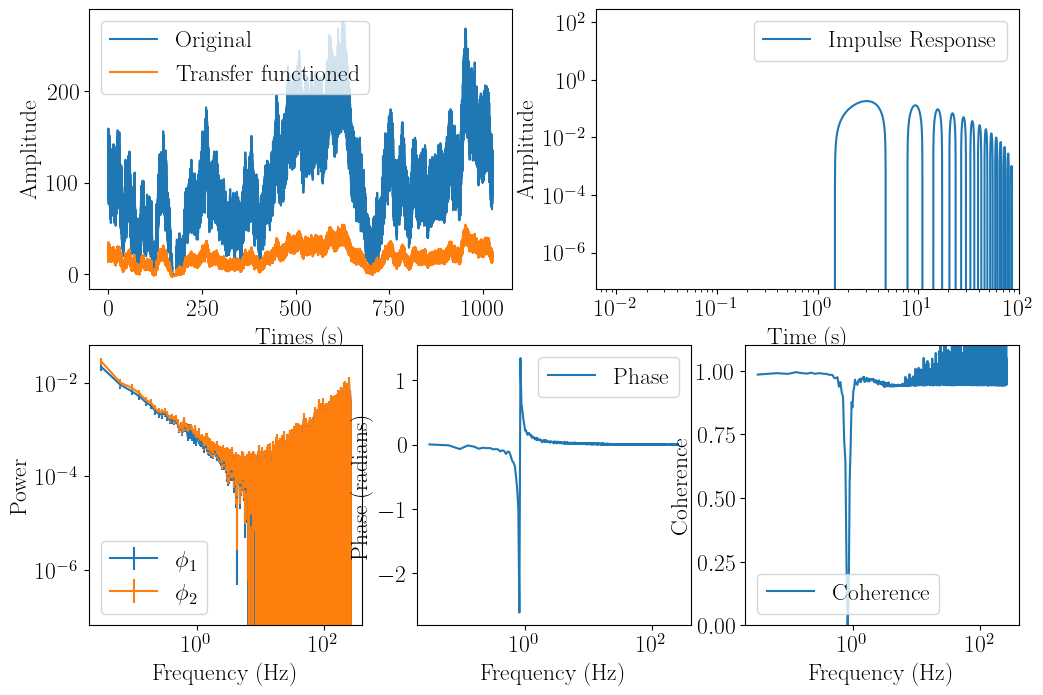

In [321]:
dt = 1/512
mean = 100
T = 1024/dt
rms = 0.5

sim = simulator.Simulator(N=int(T), mean=mean, dt=dt, rms=rms, poisson=True)
w = np.fft.rfftfreq(sim.N, d=sim.dt)[1:]
lc1 = sim.simulate(2)

t, h = frequency_to_impulse_response(w, allpass_tf, t_max=100, dt=0.01, omega_z=1.0, gamma_z=0.1)

out = apply_transfer_function(lc1.counts, h, dt)
lc2 = Lightcurve(lc1.time, out)
plot_result(lc1,lc2,t,h)

/var/folders/2y/c0w7l5s92pv0ttnyqhkd8fym0000gp/T/ipykernel_17058/3095300934.py:21: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim(0,100)
32it [00:00, 5112.67it/s]
32it [00:00, 5270.05it/s]
32it [00:00, 3002.43it/s]


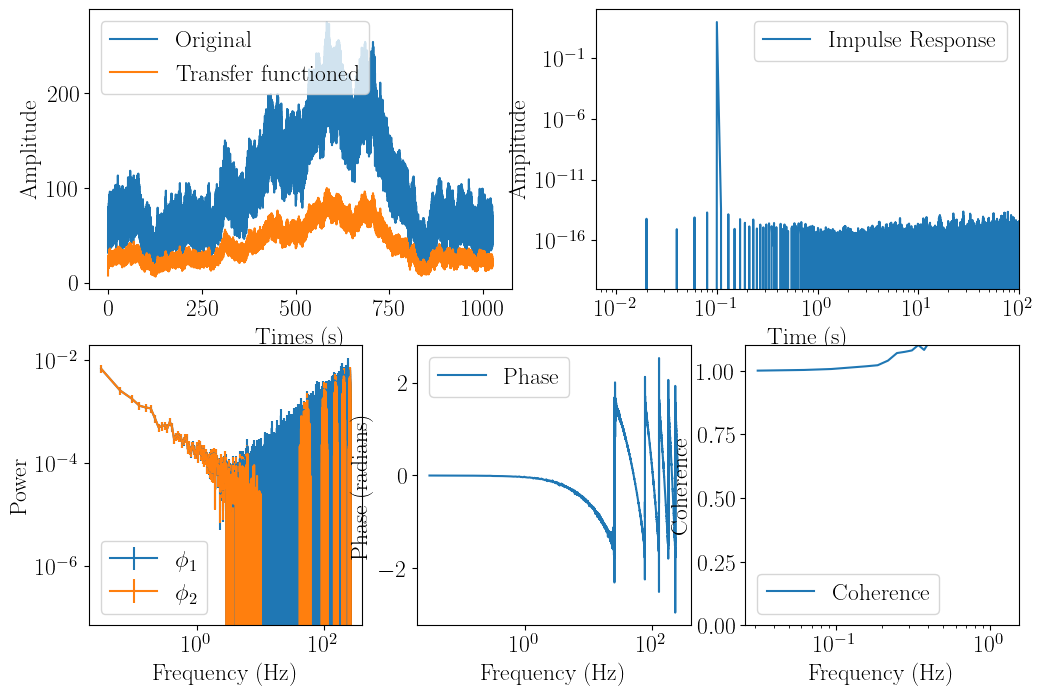

In [312]:
dt = 1/512
mean = 100
T = 1024/dt
rms = 0.5

sim = simulator.Simulator(N=int(T), mean=mean, dt=dt, rms=rms, poisson=True)
w = np.fft.rfftfreq(sim.N, d=sim.dt)[1:]
lc1 = sim.simulate(2)

t, h = frequency_to_impulse_response(w, echo_tf, t_max=100, dt=0.01, alpha=1.0, tau=0.1)

out = apply_transfer_function(lc1.counts, h, dt)
lc2 = Lightcurve(lc1.time, out)

plot_result(lc1,lc2,t,h)

/var/folders/2y/c0w7l5s92pv0ttnyqhkd8fym0000gp/T/ipykernel_17058/3095300934.py:21: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim(0,100)
32it [00:00, 5041.80it/s]
32it [00:00, 5734.82it/s]
32it [00:00, 2728.00it/s]


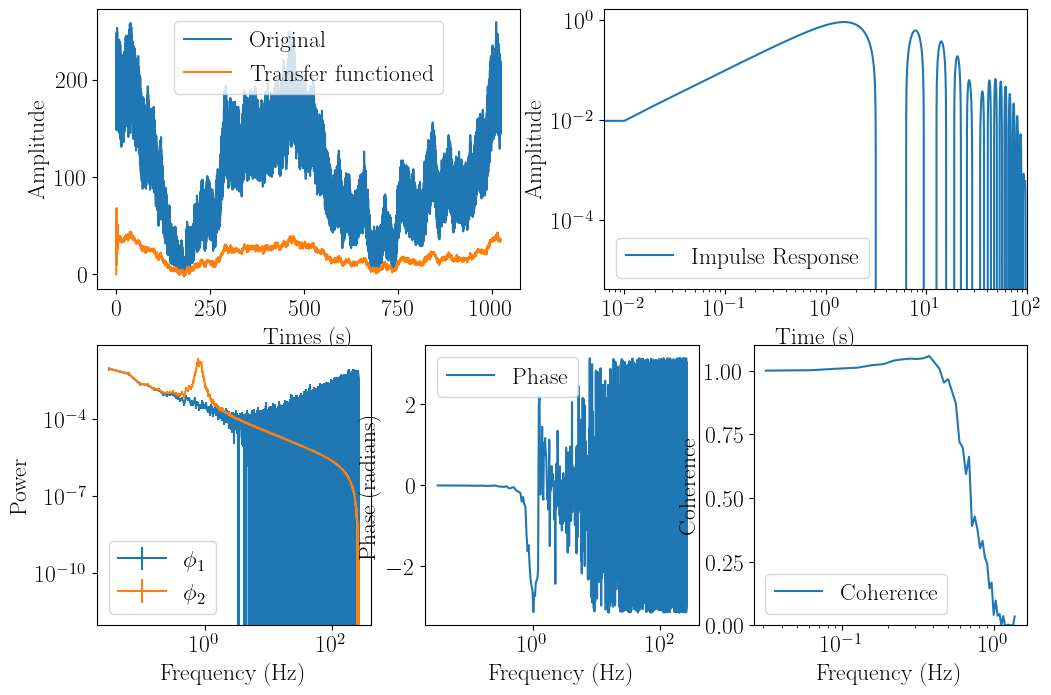

In [313]:
dt = 1/512
mean = 100
T = 1024/dt
rms = 0.5

sim = simulator.Simulator(N=int(T), mean=mean, dt=dt, rms=rms, poisson=True)
w = np.fft.rfftfreq(sim.N, d=sim.dt)[1:]
lc1 = sim.simulate(2)

t, h = frequency_to_impulse_response(w, coupled_oscillators_tf, t_max=100, dt=0.01, omega1=1.0, gamma1=0.1, omega2=1.01, gamma2=0.1, kappa=0.1)

out = apply_transfer_function(lc1.counts, h, dt)
lc2 = Lightcurve(lc1.time, out)

plot_result(lc1,lc2,t,h)

/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/simulator/simulator.py:390: UserWarning: Some bins of the light curve have counts < 0. Setting to 0
  warnings.warn("Some bins of the light curve have counts < 0. Setting to 0")
/var/folders/2y/c0w7l5s92pv0ttnyqhkd8fym0000gp/T/ipykernel_17058/3095300934.py:21: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim(0,100)
32it [00:00, 5462.44it/s]
32it [00:00, 5981.45it/s]
32it [00:00, 2871.52it/s]
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: divide by zero encountered in divide
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: invalid value encountered in sqrt
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/utils.py:492: UserWarning: SIMON says: Number of segments used in 

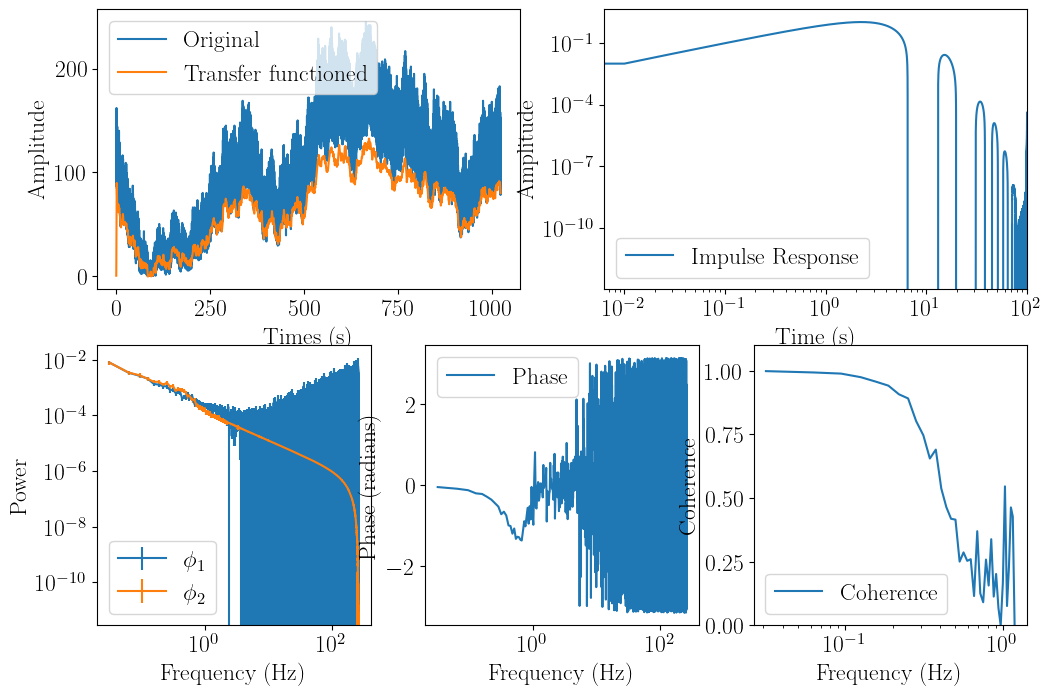

In [315]:
dt = 1/512
mean = 100
T = 1024/dt
rms = 0.5

sim = simulator.Simulator(N=int(T), mean=mean, dt=dt, rms=rms, poisson=True)
w = np.fft.rfftfreq(sim.N, d=sim.dt)[1:]
lc1 = sim.simulate(2)

t, h = frequency_to_impulse_response(w, sum_of_oscillators_tf, t_max=100, dt=0.01, params_list = [[0.5, 0.5],[0.6, 0.5]], amplitudes = [0.5, 0.5])

out = apply_transfer_function(lc1.counts, h, dt)
lc2 = Lightcurve(lc1.time, out)

plot_result(lc1,lc2,t,h)

# Changing frequency signal

/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/utils.py:492: UserWarning: SIMON says: Stingray only uses poisson err_dist at the moment. All analysis in the light curve will assume Poisson errors. Sorry for the inconvenience.
  warnings.warn("SIMON says: {0}".format(message), **kwargs)
25it [00:00, 19159.07it/s]
25it [00:00, 21772.76it/s]
25it [00:00, 17033.40it/s]
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1766: UserWarning: n_ave is below 30. Please note that the error bars on the quantities derived from the cross spectrum are only reliable for a large number of averaged powers.
  warnings.warn(
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: divide by zero encountered in divide
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))
/opt/miniconda3/envs/work/lib/python3.13/site-packages/stingray/utils.py:492: UserWarning: SIMON says: Number of segments used in averaging is significantly low. Th

Saved demo plot to figures/quasi_periodic_demo.png


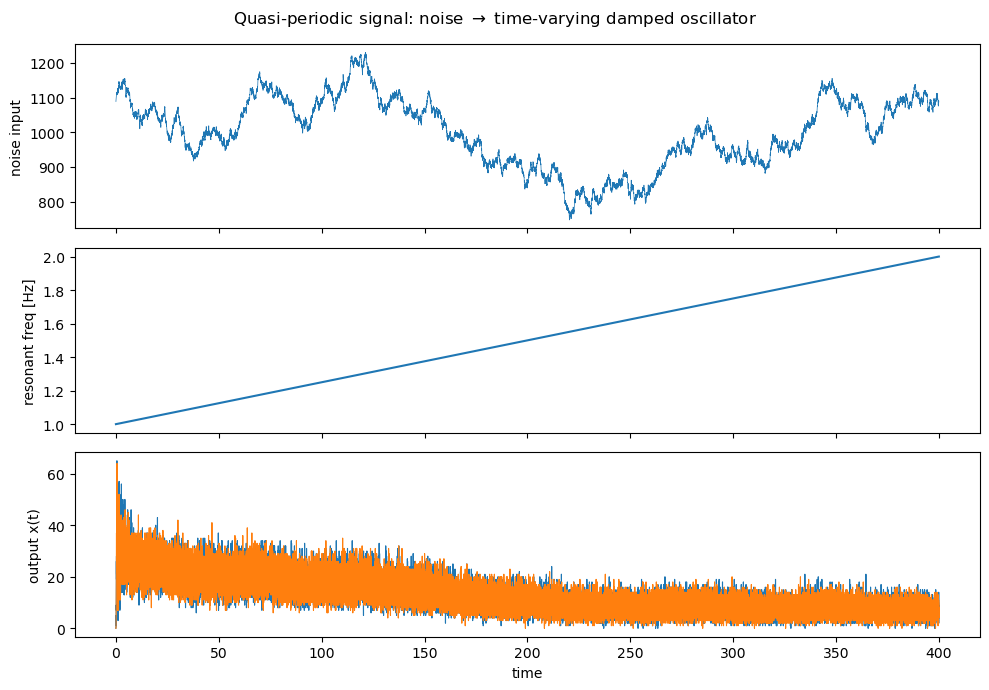

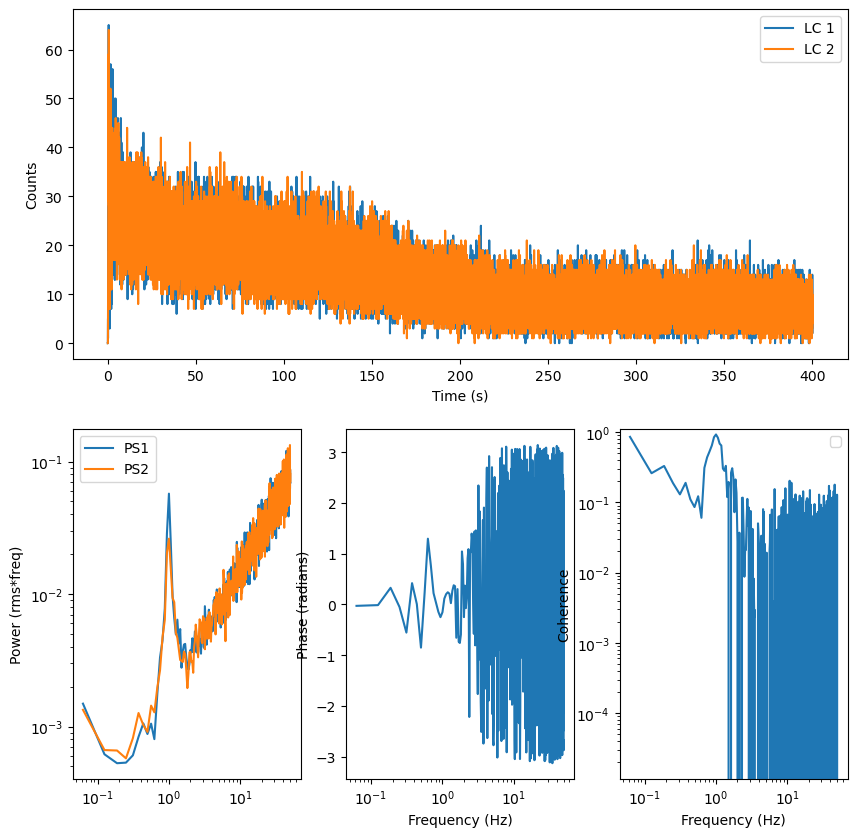

In [55]:
"""
Quasi-periodic signal generator.

Generates a signal by driving a damped harmonic oscillator with a time-varying
resonant frequency using an input noise process.

The damped harmonic oscillator obeys:
    x''(t) + 2*gamma*x'(t) + omega(t)^2 * x(t) = noise(t)

This is discretized using a state-space formulation where the oscillator is
advanced one step at a time, allowing omega to vary with time.
"""

import numpy as np


def damped_oscillator_convolve(noise, omega, gamma, dt=1.0):
    """
    Drive a damped harmonic oscillator with `noise`, where the resonant
    angular frequency `omega` varies with time.

    This is equivalent to a convolution with a damped-oscillator impulse
    response when omega is constant, but handles the time-varying case
    by stepping the state-space system forward one sample at a time.

    Parameters
    ----------
    noise : (N,) array
        Input driving noise process (the forcing term).
    omega : scalar or (N,) array
        Time-varying resonant angular frequency (rad / unit time).
        If scalar, treated as constant.
    gamma : scalar or (N,) array
        Damping rate (1 / unit time). The Q-factor is omega / (2*gamma).
        Must satisfy gamma < omega for an underdamped (oscillatory) response.
    dt : float
        Sample spacing.

    Returns
    -------
    x : (N,) array
        The oscillator position -- the quasi-periodic output signal.
    """
    noise = np.asarray(noise, dtype=float)
    N = noise.size

    omega = np.broadcast_to(np.asarray(omega, dtype=float), (N,))
    gamma = np.broadcast_to(np.asarray(gamma, dtype=float), (N,))

    x = np.zeros(N)   # position
    v = np.zeros(N)   # velocity

    # Step using the exact solution of the damped oscillator over each dt,
    # treating omega and gamma as piecewise-constant and the noise as an
    # impulsive kick at each step. This is stable for any dt and preserves
    # the oscillatory character even when omega(t) changes quickly.
    for n in range(1, N):
        w = omega[n - 1]
        g = gamma[n - 1]

        # Underdamped natural frequency
        wd_sq = w * w - g * g
        if wd_sq <= 0:
            # Critically/over-damped fallback: treat as underdamped with tiny wd
            wd = 1e-12
        else:
            wd = np.sqrt(wd_sq)

        e = np.exp(-g * dt)
        c = np.cos(wd * dt)
        s = np.sin(wd * dt)

        # Exact propagator for x'' + 2*g*x' + w^2*x = 0 over one step of dt
        a11 = e * (c + (g / wd) * s)
        a12 = e * s / wd
        a21 = -e * (w * w / wd) * s
        a22 = e * (c - (g / wd) * s)

        x_new = a11 * x[n - 1] + a12 * v[n - 1]
        v_new = a21 * x[n - 1] + a22 * v[n - 1]

        # Add the driving noise as an impulse on the velocity
        # (acceleration integrated over dt).
        v_new += noise[n - 1] * dt

        x[n] = x_new
        v[n] = v_new

    return x


import matplotlib.pyplot as plt
from stingray import simulator
import stingray

rng = np.random.default_rng(0)
N = 40000
dt = 0.01
t = np.arange(N) * dt

mean = 1000
rms = 0.1

sim = simulator.Simulator(N=int(N), mean=mean, dt=dt, rms=rms, poisson=False)
w = np.fft.rfftfreq(sim.N, d=sim.dt)[1:]
lc1 = sim.simulate(2)

# --- Example usage ---

# Resonant frequency sweeps from ~1 Hz to ~4 Hz over the run
f_t = 1.0 + 1.0 * (t / t[-1])
omega_t = 2 * np.pi * f_t

# Light damping -> high Q, clearly oscillatory
gamma_1 = 0.3
gamma_2 = 0.5

counts_1 = np.random.poisson(damped_oscillator_convolve(lc1.counts, omega_t, gamma_1, dt=dt))
counts_2 = np.random.poisson(damped_oscillator_convolve(lc1.counts, omega_t, gamma_2, dt=dt))

lc_1 = stingray.Lightcurve(t, counts_1, dt=dt)
lc_2 = stingray.Lightcurve(t, counts_2, dt=dt)

ps1 = stingray.AveragedPowerspectrum.from_lightcurve(lc_1, norm="frac", segment_size=16)
ps2 = stingray.AveragedPowerspectrum.from_lightcurve(lc_2, norm="frac", segment_size=16)

avgcs = stingray.AveragedCrossspectrum.from_lightcurve(lc_1, lc_2, norm="frac", segment_size=16)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(t, lc1.counts, lw=0.5)
axes[0].set_ylabel("noise input")
axes[1].plot(t, f_t)
axes[1].set_ylabel("resonant freq [Hz]")
axes[2].plot(t, lc_1.counts, lw=0.8,label="gamma=0.3")
axes[2].plot(t, lc_2.counts, lw=0.8,label="gamma=0.5")
axes[2].set_ylabel("output x(t)")
axes[2].set_xlabel("time")
fig.suptitle("Quasi-periodic signal: noise $\\to$ time-varying damped oscillator")
fig.tight_layout()
fig.savefig("figures/quasi_periodic_demo.png", dpi=120)
print("Saved demo plot to figures/quasi_periodic_demo.png")

fig = plt.figure(figsize=(10, 10))

ax1 = plt.subplot(2,1,1)

ax1.plot(lc_1.time, lc_1.counts, label="LC 1")
ax1.plot(lc_2.time, lc_2.counts, label="LC 2")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Counts")
ax1.legend()

ax2 = plt.subplot(2,3,4)

ax2.plot(ps1.freq, ps1.power*ps1.freq, label="PS1")
ax2.plot(ps2.freq, ps2.power*ps2.freq, label="PS2")
ax2.set_ylabel("Power (rms*freq)")
ax2.legend()
ax2.loglog()

ax3 = plt.subplot(2,3,5)
ax3.plot(avgcs.freq, np.angle(avgcs.power), label="Phase")
ax3.set_xlabel("Frequency (Hz)")
ax3.set_ylabel("Phase (radians)")
ax3.set_xscale("log")

ax4 = plt.subplot(2,3,6)
ax4.plot(avgcs.freq, avgcs.coherence()[0])
ax4.set_xlabel("Frequency (Hz)")
ax4.set_ylabel("Coherence")
ax4.legend()
ax4.loglog()
ax4.set_ylim(0,1.1)

plt.show()

[1.        1.0000025 1.000005  ... 1.999995  1.9999975 2.       ]
Saved demo plot to figures/quasi_periodic_demo.png


250it [00:00, 50180.70it/s]
250it [00:00, 51145.06it/s]


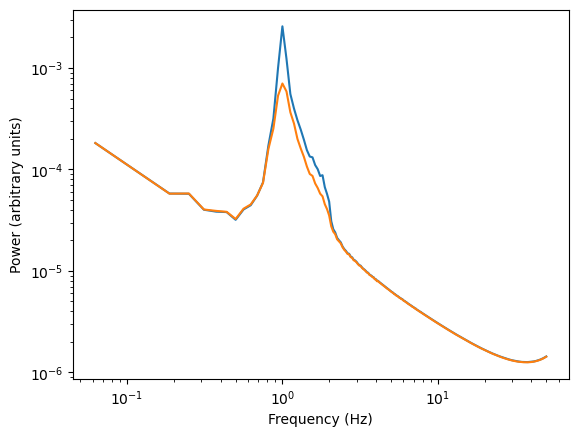

250it [00:00, 26607.53it/s]


In [78]:
import stingray
from stingray import simulator

rng = np.random.default_rng(0)
N = 400000
dt = 0.01
t = np.arange(N) * dt

mean = 10000
rms = 0.25

sim = simulator.Simulator(N=int(N), mean=mean, dt=dt, rms=rms, poisson=False)
w = np.fft.rfftfreq(sim.N, d=sim.dt)[1:]
lc1 = sim.simulate(2)

# Resonant frequency sweeps from ~1 Hz to ~4 Hz over the run
f_t = 1.0 + 1.0 * (t / t[-1])
print(f_t)
omega_t = 2 * np.pi * f_t

# Light damping -> high Q, clearly oscillatory
gamma_1 = 0.3
gamma_2 = 0.6

x_1 = damped_oscillator_convolve(lc1.counts, omega_t, gamma_1, dt=dt)
x_2 = damped_oscillator_convolve(lc1.counts, omega_t, gamma_2, dt=dt)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(t, lc1.counts, lw=0.5)
axes[0].set_ylabel("noise input")
axes[1].plot(t, f_t)
axes[1].set_ylabel("resonant freq [Hz]")
axes[2].plot(t, x_1, lw=0.8,label="gamma=0.3")
axes[2].plot(t, x_2, lw=0.8,label="gamma=0.5")
axes[2].legend()
axes[2].set_ylabel("output x(t)")
axes[2].set_xlabel("time")
fig.suptitle("Quasi-periodic signal: noise $\\to$ time-varying damped oscillator")
fig.tight_layout()
fig.savefig("figures/quasi_periodic_demo.png", dpi=120)
print("Saved demo plot to figures/quasi_periodic_demo.png")
plt.close()

constant = 100
counts_1 = np.random.poisson(x_1 * constant * 0.1 + constant)
counts_2 = np.random.poisson(x_2 * constant * 0.1 + constant)
counts_1 = x_1 * constant * 0.1 + constant
counts_2 = x_2 * constant * 0.1 + constant

lc_1 = stingray.Lightcurve(t, counts_1, dt=dt)
lc_2 = stingray.Lightcurve(t, counts_2, dt=dt)

ps1 = stingray.AveragedPowerspectrum.from_lightcurve(lc_1, norm="frac", segment_size=16)
ps2 = stingray.AveragedPowerspectrum.from_lightcurve(lc_2, norm="frac", segment_size=16)

plt.plot(ps1.freq, ps1.freq*(ps1.power),label=r"$\gamma=0.3$")
plt.plot(ps2.freq, ps2.freq*(ps2.power),label=r"$\gamma=0.5$")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (arbitrary units)")
plt.xscale("log")
plt.yscale("log")
plt.show()

avgcs = stingray.AveragedCrossspectrum.from_lightcurve(lc_1, lc_2, segment_size=16, norm="frac")

/var/folders/2y/c0w7l5s92pv0ttnyqhkd8fym0000gp/T/ipykernel_32239/2959687446.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


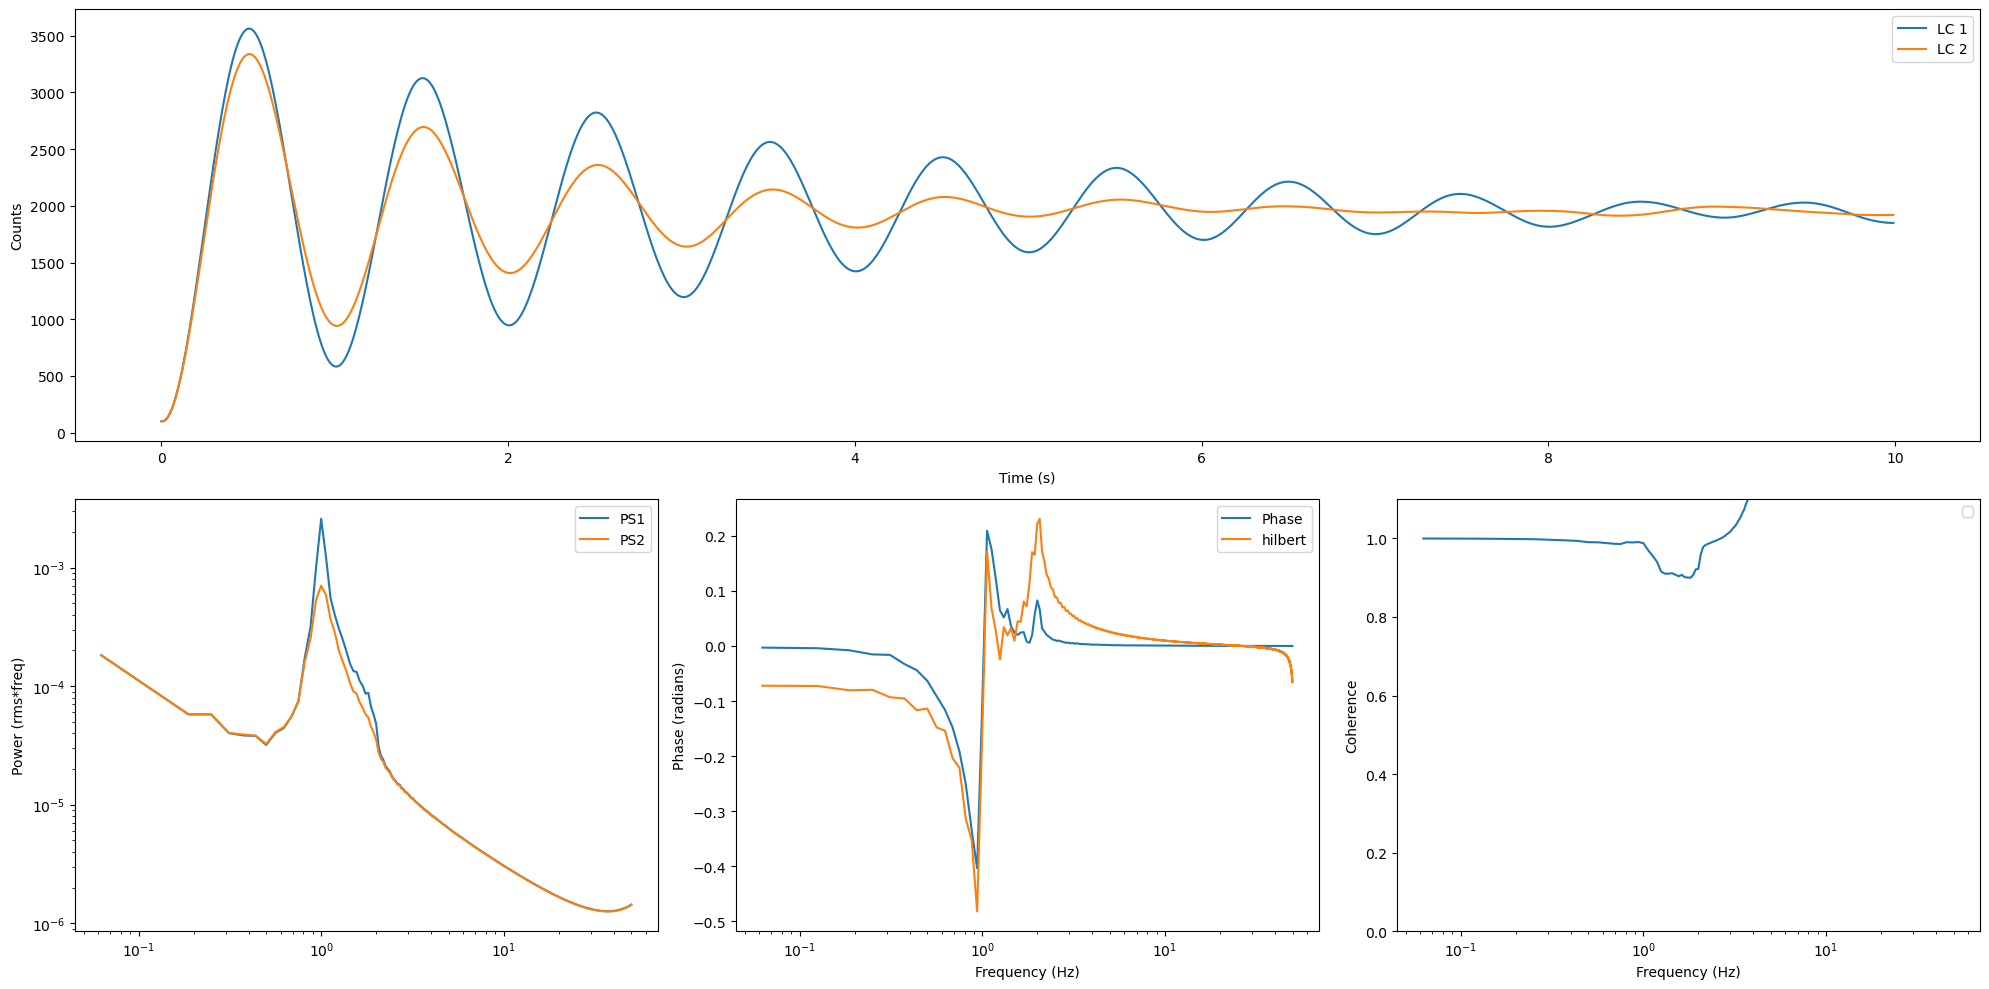

In [82]:
from scipy.signal import hilbert
fig = plt.figure(figsize=(20, 10))

ax1 = plt.subplot(2,1,1)

ax1.plot(lc_1.time[lc_1.time<10], lc_1.counts[lc_1.time<10], label="LC 1")
ax1.plot(lc_2.time[lc_2.time<10], lc_2.counts[lc_2.time<10], label="LC 2")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Counts")
ax1.legend()

ax2 = plt.subplot(2,3,4)

ax2.plot(ps1.freq, ps1.power*ps1.freq, label="PS1")
ax2.plot(ps2.freq, ps2.power*ps2.freq, label="PS2")
ax2.set_ylabel("Power (rms*freq)")
ax2.legend()
ax2.loglog()

ax3 = plt.subplot(2,3,5)
ax3.plot(avgcs.freq, np.angle(avgcs.power), label="Phase")

log_power_ratio = np.log(ps1.power/ps2.power)
delta_theta = np.imag(hilbert(log_power_ratio))/2
ax3.plot(ps1.freq, delta_theta, label="hilbert")
ax3.legend()
ax3.set_xlabel("Frequency (Hz)")
ax3.set_ylabel("Phase (radians)")
ax3.set_xscale("log")

ax4 = plt.subplot(2,3,6)
ax4.plot(avgcs.freq, avgcs.coherence()[0])
ax4.set_xlabel("Frequency (Hz)")
ax4.set_ylabel("Coherence")
ax4.legend()
ax4.set_xscale("log")
ax4.set_ylim(0,1.1)

plt.tight_layout()

plt.show()